# 1-basic Model loading


#### Imports and Utils

In [ ]:
import os
import sys
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from tqdm import tqdm
import pdb
import random
from itertools import product
from collections import namedtuple
from collections import defaultdict
import math
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
import ast

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch import optim
from torch.utils.data import Sampler
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset, TensorDataset

from scipy.integrate import quad
from sklearn.model_selection import train_test_split
from scipy.stats import linregress
from scipy.special import expit
from scipy.spatial import distance

import networkx as nx
import gravis as gv
import seaborn as sns

print("USING pytorch VERSION: ", torch.__version__)

USING pytorch VERSION:  1.10.2


In [ ]:
def visualize_learned_GRN_And_Or(weight_act='empty',weight_rep='empty',target_name=None,
                                 act_name=None,rep_name=None):

    G = nx.DiGraph()


    if(not weight_act is 'empty'):
        n_act=len(weight_act)
    else:
        n_act=0
    if(not weight_rep is 'empty'):
        n_rep=len(weight_rep)
    else:
        n_rep=0


    if(target_name==None):
        #_____nodes:
        for i in range(n_act):
                G.add_node("A"+str(i), level=0)
        for i in range(n_rep):
                G.add_node("R"+str(i), level=0)
        G.add_node("T", level=1)

        # edges
        G.add_edges_from( [ ("A"+ str(i),'T' ) for i in range(n_act)  ]  )
        G.add_edges_from( [ ("R"+ str(i),'T' ) for i in range(n_rep)  ]  )

    if(target_name!=None):
        #_____nodes:
        for i in range(n_act):
                G.add_node(act_name[i], level=0)
        for i in range(n_rep):
                G.add_node(rep_name[i], level=0)
        G.add_node(' '+target_name, level=1)

        # edges
        G.add_edges_from( [ (act_name[i],' '+target_name ) for i in range(n_act)  ]  )
        G.add_edges_from( [ (rep_name[i],' '+target_name ) for i in range(n_rep)  ]  )


    pos = nx.multipartite_layout(G, subset_key="level",scale=10)
    node_color=['#4168b0'  for i in range(n_act) ]+ ['#dd503d'  for i in range(n_rep) ] +['white']


    nx.draw_networkx_nodes(G, pos,node_color='dimgray',node_size=310)

    nx.draw(G, pos, with_labels=True,node_size=300,font_size=7,
            edge_color= [(plt.cm.Blues(abs(weight_act[i])/abs(weight_act).max()))   for i in range(n_act) ]+
                        [(plt.cm.Blues(abs(weight_rep[i])/abs(weight_rep).max()))   for i in range(n_rep) ],
            node_color=node_color,
            arrowsize=2,
            width=2,
            )

    plt.show()

#### Model Class Definitions


In [ ]:
class L12Smooth(nn.Module):
    def __init__(self):
        super(L12Smooth, self).__init__()

    def forward(self, input_tensor, a=0.05):
        """input: predictions"""
        return l12_smooth(input_tensor, a)


def l12_smooth(input_tensor, a=0.05):
    """Smoothed L1/2 norm"""
    if type(input_tensor) == list:
        return sum([l12_smooth(tensor) for tensor in input_tensor])

    smooth_abs = torch.where(torch.abs(input_tensor) < a,
                             torch.pow(input_tensor, 4) / (-8 * a ** 3) + torch.square(input_tensor) * 3 / 4 / a + 3 * a / 8,
                             torch.abs(input_tensor))

    return torch.sum(torch.sqrt(smooth_abs))

In [ ]:
class AndOrSampler(Sampler[int]):
    def __init__(self, data_source, replacement  = False,
                    num_samples = None, generator=None):
            self.data_source = data_source
            self.replacement = replacement
            self.num_samples = num_samples if num_samples else len(data_source)
            self.generator = generator

    def __iter__(self):
        n = len(self.data_source)
        if self.generator is None:
            seed = int(torch.empty((), dtype=torch.int64).random_().item())
            generator = torch.Generator()
            generator.manual_seed(seed)
        else:
            generator = self.generator

        if self.replacement:
            for _ in range(self.num_samples // 32):
                yield from torch.randint(high=n, size=(32,), dtype=torch.int64, generator=generator).tolist()
            yield from torch.randint(high=n, size=(self.num_samples % 32,), dtype=torch.int64, generator=generator).tolist()
        else:
            for _ in range(self.num_samples // n):
                yield from torch.randperm(n, generator=generator).tolist()
            yield from torch.randperm(n, generator=generator).tolist()[:self.num_samples % n]


    def __len__(self) -> int:
        return self.num_samples

In [ ]:
# updated for and+or two inputs
class ExpressionData_And_Or(Dataset):
    def __init__(self, x_act,x_rep, y, t):
        if isinstance(x_act, np.ndarray):
            x_act = torch.from_numpy(x_act).type(torch.FloatTensor)
        if isinstance(x_rep, np.ndarray):
            x_rep = torch.from_numpy(x_rep).type(torch.FloatTensor)
        if isinstance(y, np.ndarray):
            y = torch.from_numpy(y).type(torch.FloatTensor).reshape(-1, 1)
        if isinstance(t, np.ndarray):
            t = torch.from_numpy(t).type(torch.FloatTensor).reshape(-1, 1)

        # Why it is needed here??
        assert x_act.size(0) == x_rep.size(0) == y.size(0) == t.size(0), "Size mismatch between time lengths"

        self.length = x_act.size(0)

        self.x_data_act = x_act
        self.x_data_rep = x_rep
        self.y_data = y
        self.t_data = t

    def __getitem__(self, index):
        return self.x_data_act[index], self.x_data_rep[index], self.y_data[index], self.t_data[index]

    def __len__(self):
        return self.length

In [ ]:
class And_Or_Layer(nn.Module):
    def __init__(self, in_features_act,in_features_rep, out_features): # seperating activators and rep features inputs
        super(And_Or_Layer, self).__init__()

        self.weight_and = nn.Parameter(torch.randn(out_features, in_features_act))
        self.bias_and = nn.Parameter(torch.ones(in_features_act))

        self.weight_or = nn.Parameter(torch.zeros(out_features, in_features_rep))
        self.bias_or =  -nn.Parameter(torch.ones(in_features_rep))


    def forward(self, x_act,x_rep):

        y_act =  torch.abs(  torch.prod(   torch.mul(  (x_act), self.weight_and  ) +
                                    torch.sigmoid((self.bias_and)*10)  ,dim=1 )  )

        #this version has a sharp sigmoid in biase
        y_rep =  1-torch.abs(  torch.sum(   torch.mul(  (x_rep), self.weight_or  ) +
                                    torch.sigmoid((self.bias_or)*10  )  ,dim=1 )  )

        # this might need to improve:
        y= y_act*y_rep
        return y

class And_Or_Network(nn.Module):
    def __init__(self, num_genes_act,num_genes_rep):
        super().__init__()
        self.regulator_layer = And_Or_Layer(num_genes_act,num_genes_rep, 1)

    def forward(self, x_act,x_rep):
        y = self.regulator_layer(x_act,x_rep)
        return y


### Training Loop Definition

In [ ]:
nn.SmoothL1Loss()
nn.MSELoss()

MSELoss()

In [ ]:
# Training Loop
def training_loop_And_Or (model, data_loader, criterion= nn.MSELoss(),
                          epochs=100, regularization_lambda=0.01, verbose=False,
                          callback_val=0.01,
                          randomize_gene_selection=False,
                          lambda_heirarchy=0.0,W_h_A=torch.zeros(1)):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []  # List to store loss values

    pbar = tqdm(range(epochs))

    for epoch in pbar:
        running_loss = 0.0
        for inputs_act,inputs_rep, labels, time in data_loader:
            # zero the parameter gradients
            optimizer.zero_grad()
            # forward + backward + optimize
            outputs = model(inputs_act,inputs_rep)

            loss = criterion((outputs), (labels))

            # L0.5 regularization
            l0_5_norm = sum(l12_smooth(p) for p in model.parameters())

            w_A=model.regulator_layer.weight_and
            l_heirrchy=l12_smooth(W_h_A * w_A)

            loss = loss + regularization_lambda * l0_5_norm + lambda_heirarchy * l_heirrchy

            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()

        # Append the running loss to the list after each epoch
        losses.append(running_loss / len(data_loader))
        pbar.set_description(f"Epoch: {epoch}, Loss: {running_loss / len(data_loader)}")

        if running_loss <= callback_val:
          break

    return model, losses

### Noisy AND_OR_NN

In [ ]:
def create_synthetic_data(A, R, GRN_A, GRN_R, T,reg_skip=0, plot=False,
                          noise_level_dropout=0.0,noise_level_biological=0.0):
    def square_pulse(x, center, duration):
      signal = np.where((center - duration <= x) & (x <= center + duration), 1.0, 0.0)
      return signal.astype(float)

    syn_data_input_act = np.array([square_pulse(T, center, duration) for center, duration in A], dtype=float).T
    syn_data_input_rep = np.array([square_pulse(T, center, duration) for center, duration in R], dtype=float).T

    activators = np.prod(syn_data_input_act[:,GRN_A], axis=1)
    repressors = np.prod(1 - syn_data_input_rep[:, GRN_R], axis=1)


    # Emulate biological noise:

    for i in range(syn_data_input_act.shape[1]):
        syn_data_input_act[np.random.rand(len(activators)) < noise_level_biological,i] = 0

    for i in range(syn_data_input_rep.shape[1]):
        syn_data_input_rep[np.random.rand(len(repressors)) < noise_level_biological,i] = 0



    syn_data_output = activators * repressors


    # Emulate dropouts:
    syn_data_output[np.random.rand(len(syn_data_output)) < noise_level_dropout] = 0

    for i in range(syn_data_input_act.shape[1]):
        syn_data_input_act[np.random.rand(len(activators)) < noise_level_dropout,i] = 0

    for i in range(syn_data_input_rep.shape[1]):
        syn_data_input_rep[np.random.rand(len(repressors)) < noise_level_dropout,i] = 0



    #time skip:
    syn_data_output = np.roll(activators * repressors, reg_skip)
    syn_data_output[:reg_skip] = None

    if plot:
        plt.figure(figsize=(20, 6))
        for i, activator in enumerate(syn_data_input_act.T):
            plt.fill_between(T, activator * (20 / (20 + i)), label=f'Activator {i}', alpha=0.2)
        for i, repressor in enumerate(syn_data_input_rep.T):
            plt.fill_between(T, -repressor * (10 / (20 + i)), label=f'Repressor {i}', alpha=0.3)

        plt.scatter(T, activators / 2, linestyle="--", label='Activator', c="blue", alpha=0.3)
        plt.scatter(T, -(1-repressors) / 2, linestyle="--", label='Repressor', c="red", alpha=0.3)
        plt.scatter(T, syn_data_output, linestyle="-", label='Function', c="black", alpha=0.3)

        plt.title('Gene Pulse Signals and Target')
        plt.xlabel('Time')
        plt.ylabel('Signal')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

    # making sure nothing is giving us NAN and all the corresponding time points are cleaned up
    syn_data_input_act=syn_data_input_act[reg_skip:]
    syn_data_input_rep=syn_data_input_rep[reg_skip:]
    syn_data_output=syn_data_output[reg_skip:]

    return torch.tensor(syn_data_input_act, dtype=torch.float32), torch.tensor(syn_data_input_rep, dtype=torch.float32), torch.tensor(syn_data_output, dtype=torch.float32)

# 2 loading the data from file

In [ ]:
#_______loading the data
expression=pd.read_csv('z3_expression.txt',sep='\t')

PT=pd.read_csv('normal_PT.csv',index_col=0)
PT=PT.loc[expression.index]
PT=torch.tensor(PT['PT']).float()

g_g_interactions=pd.read_csv('z3_interaction.txt',sep='\t')
g_g_interactions.index=g_g_interactions['to.gene']
gene_list=list(expression.columns)

In [ ]:
#syn_data_output
# syn_data_input_act
#syn_data_input_rep
# T


In [ ]:
plt.rcParams['figure.figsize'] = (5.0, 4.0)

Bug:
No repressor doesnt work: in w_rep in heaside get error
no activator doesnt work

# running multiple times and storing the coefs of As and Rs

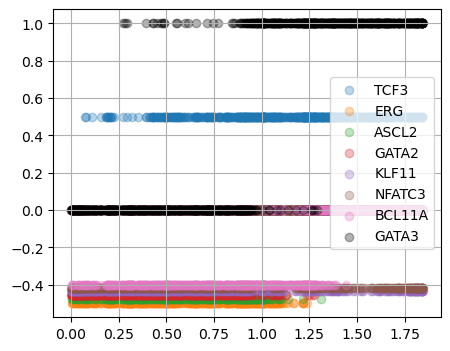

gene  GATA3  run # 0


Epoch: 169, Loss: 0.07873890007084067: 100%|██| 170/170 [00:07<00:00, 21.55it/s]


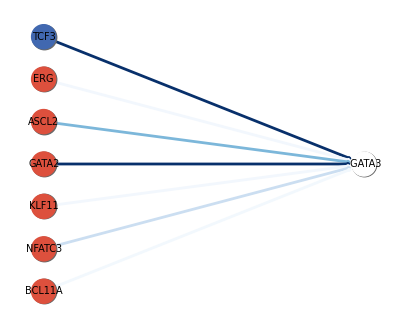

gene  GATA3  run # 1


Epoch: 169, Loss: 0.09293311834335327: 100%|██| 170/170 [00:07<00:00, 21.95it/s]


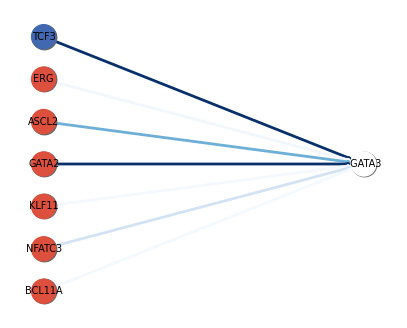

gene  GATA3  run # 2


Epoch: 169, Loss: 0.08912730555642735: 100%|██| 170/170 [00:08<00:00, 19.96it/s]


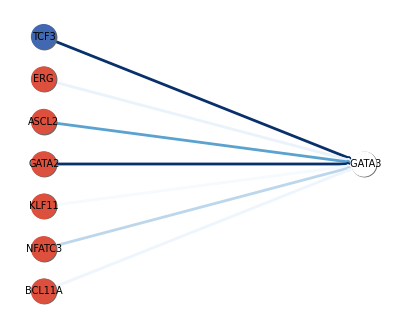

gene  GATA3  run # 3


Epoch: 169, Loss: 0.0871738540855321: 100%|███| 170/170 [00:10<00:00, 15.84it/s]


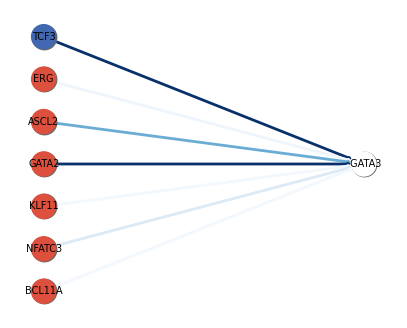

gene  GATA3  run # 4


Epoch: 169, Loss: 0.0907311500473456: 100%|███| 170/170 [00:19<00:00,  8.66it/s]


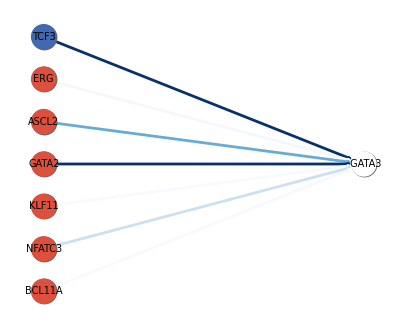

gene  GATA3  run # 5


Epoch: 169, Loss: 0.09197052229534496: 100%|██| 170/170 [00:09<00:00, 18.81it/s]


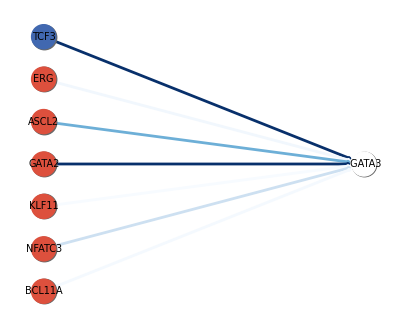

gene  GATA3  run # 6


Epoch: 169, Loss: 0.08213911205530167: 100%|██| 170/170 [00:08<00:00, 19.94it/s]


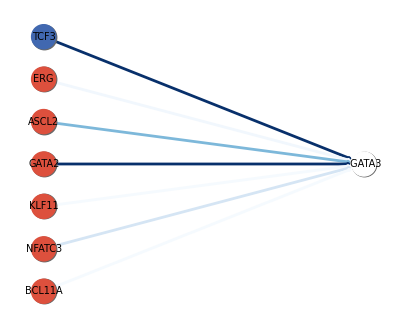

gene  GATA3  run # 7


Epoch: 169, Loss: 0.08157809485088695: 100%|██| 170/170 [00:07<00:00, 24.24it/s]


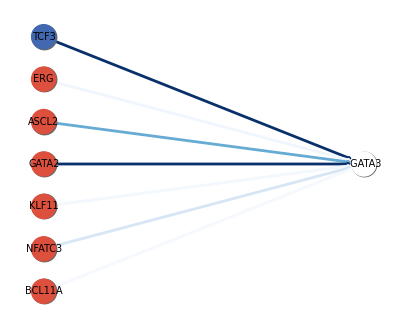

gene  GATA3  run # 8


Epoch: 169, Loss: 0.08372504264116287: 100%|██| 170/170 [00:09<00:00, 17.98it/s]


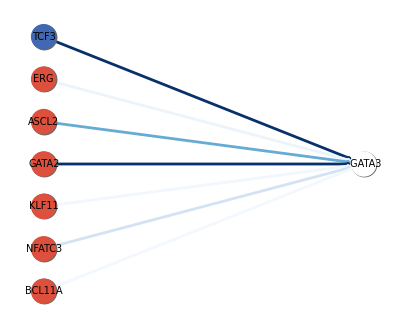

gene  GATA3  run # 9


Epoch: 169, Loss: 0.0844980159943754: 100%|███| 170/170 [00:13<00:00, 12.93it/s]


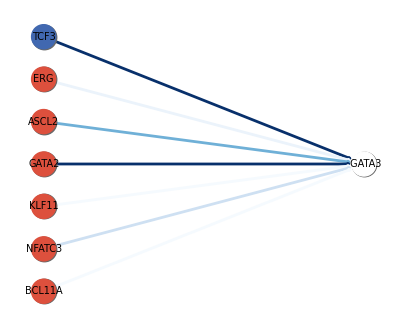

['TCF3'] ['ASCL2', 'GATA2']
GATA3 *= ( TCF3 ) and not (ASCL2 or GATA2 )


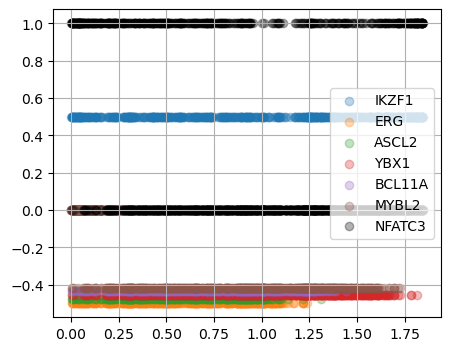

gene  NFATC3  run # 0


Epoch: 169, Loss: 0.12581743029030887: 100%|██| 170/170 [00:09<00:00, 18.83it/s]


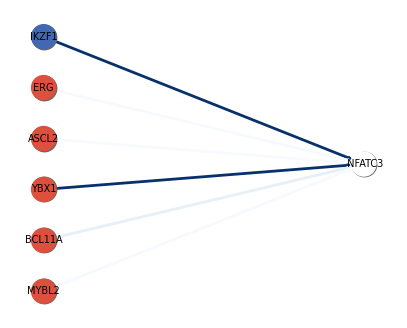

gene  NFATC3  run # 1


Epoch: 169, Loss: 0.11047047579830344: 100%|██| 170/170 [00:08<00:00, 20.50it/s]


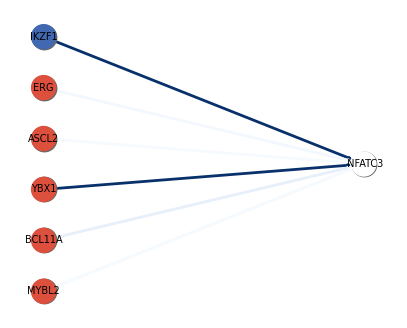

gene  NFATC3  run # 2


Epoch: 169, Loss: 0.11579085751013322: 100%|██| 170/170 [00:07<00:00, 21.79it/s]


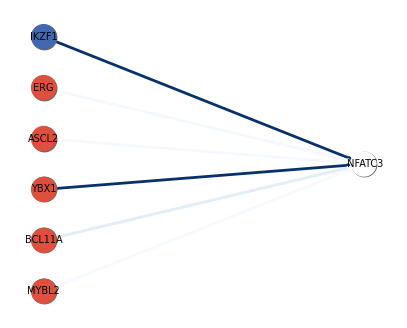

gene  NFATC3  run # 3


Epoch: 169, Loss: 0.10440840030258353: 100%|██| 170/170 [00:07<00:00, 21.35it/s]


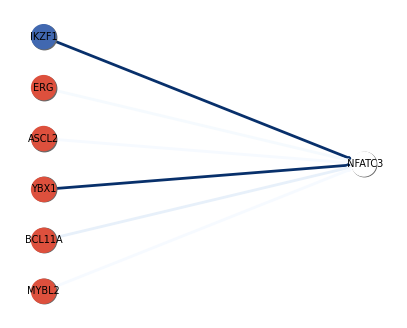

gene  NFATC3  run # 4


Epoch: 169, Loss: 0.1178508306091482: 100%|███| 170/170 [00:07<00:00, 23.91it/s]


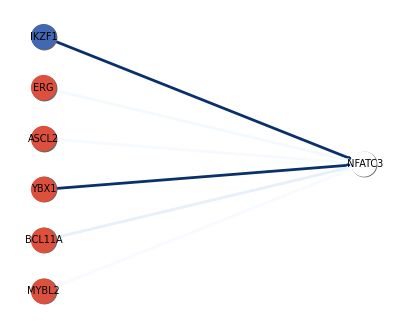

gene  NFATC3  run # 5


Epoch: 169, Loss: 0.11038897017186339: 100%|██| 170/170 [00:06<00:00, 24.48it/s]


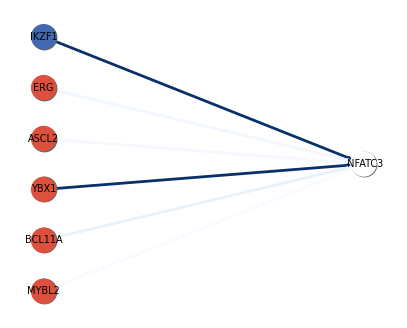

gene  NFATC3  run # 6


Epoch: 169, Loss: 0.10859337110411037: 100%|██| 170/170 [00:06<00:00, 24.77it/s]


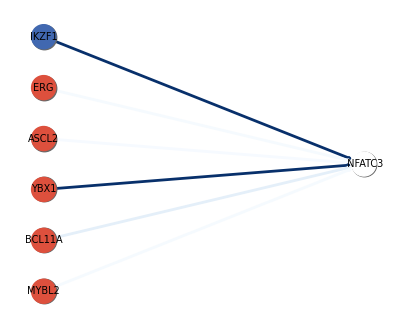

gene  NFATC3  run # 7


Epoch: 169, Loss: 0.11529590866782448: 100%|██| 170/170 [00:06<00:00, 24.31it/s]


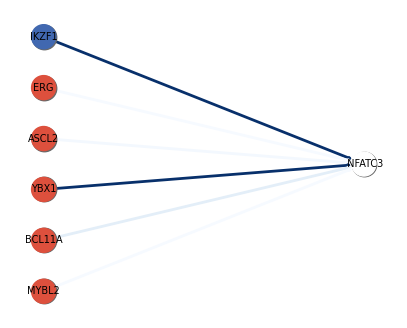

gene  NFATC3  run # 8


Epoch: 169, Loss: 0.12753065675497055: 100%|██| 170/170 [00:06<00:00, 24.32it/s]


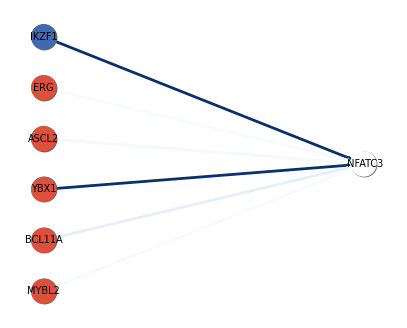

gene  NFATC3  run # 9


Epoch: 169, Loss: 0.10349813916466453: 100%|██| 170/170 [00:06<00:00, 24.70it/s]


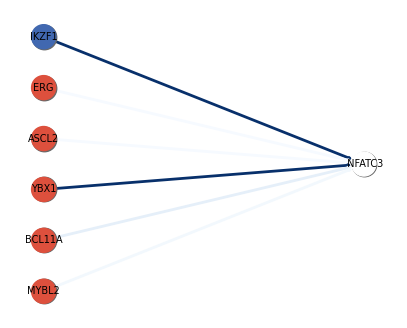

['IKZF1'] ['YBX1']
NFATC3 *= ( IKZF1 ) and not (YBX1 )


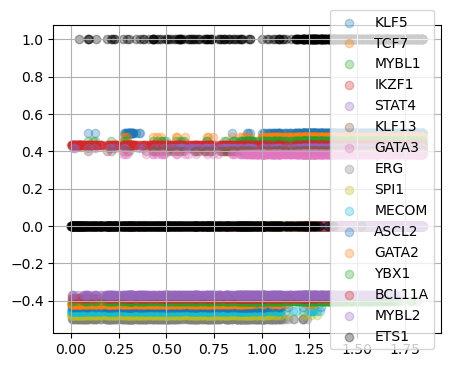

gene  ETS1  run # 0


Epoch: 169, Loss: 0.11603798310865056: 100%|██| 170/170 [00:07<00:00, 24.10it/s]


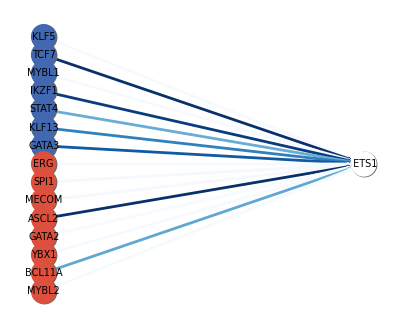

gene  ETS1  run # 1


Epoch: 169, Loss: 0.11181162365458229: 100%|██| 170/170 [00:07<00:00, 23.67it/s]


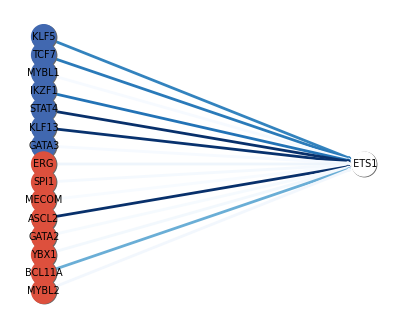

gene  ETS1  run # 2


Epoch: 169, Loss: 0.08954107084057548: 100%|██| 170/170 [00:06<00:00, 24.42it/s]


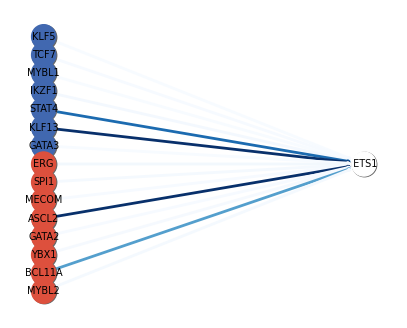

gene  ETS1  run # 3


Epoch: 169, Loss: 0.09915514290332794: 100%|██| 170/170 [00:06<00:00, 24.79it/s]


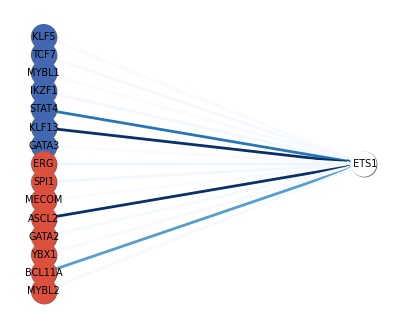

gene  ETS1  run # 4


Epoch: 169, Loss: 0.2031272758137096: 100%|███| 170/170 [00:06<00:00, 24.37it/s]


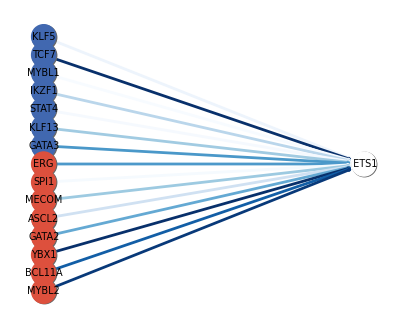

gene  ETS1  run # 5


Epoch: 169, Loss: 0.10031354088674892: 100%|██| 170/170 [00:06<00:00, 24.88it/s]


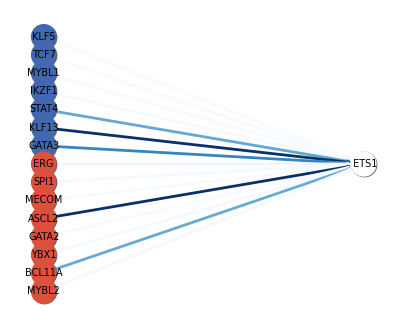

gene  ETS1  run # 6


Epoch: 169, Loss: 0.10709730535745621: 100%|██| 170/170 [00:07<00:00, 24.02it/s]


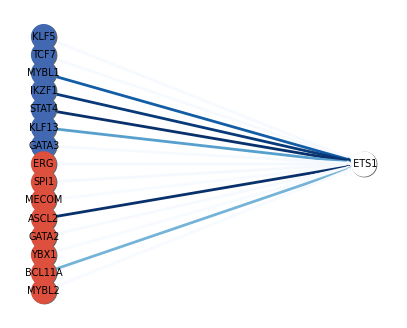

gene  ETS1  run # 7


Epoch: 169, Loss: 0.10372246259992773: 100%|██| 170/170 [00:06<00:00, 24.89it/s]


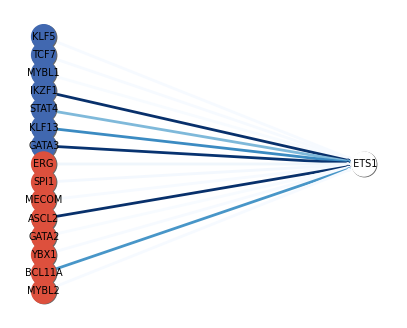

gene  ETS1  run # 8


Epoch: 169, Loss: 0.08848975056951697: 100%|██| 170/170 [00:06<00:00, 24.68it/s]


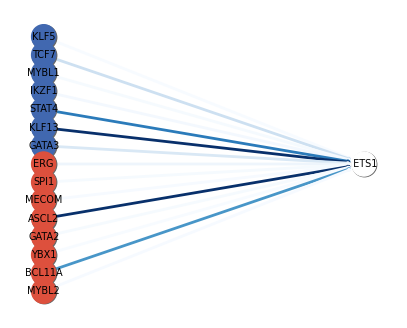

gene  ETS1  run # 9


Epoch: 169, Loss: 0.102668242698366: 100%|████| 170/170 [00:06<00:00, 24.75it/s]


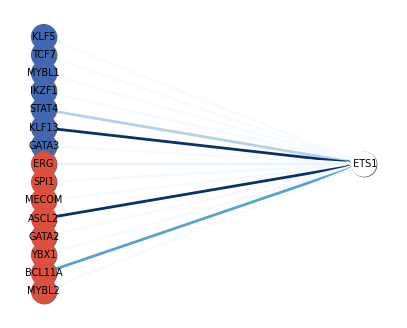

['STAT4', 'KLF13'] ['ASCL2', 'BCL11A']
ETS1 *= ( STAT4 and KLF13 ) and not (ASCL2 or BCL11A )


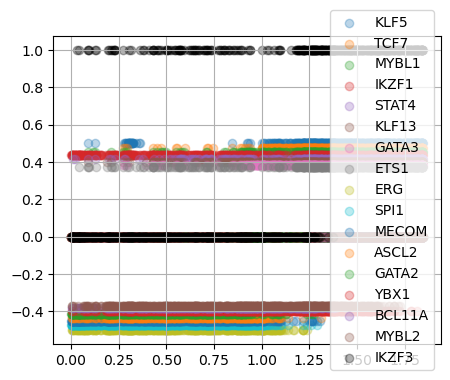

gene  IKZF3  run # 0


Epoch: 169, Loss: 0.09921306778084148: 100%|██| 170/170 [00:06<00:00, 24.58it/s]


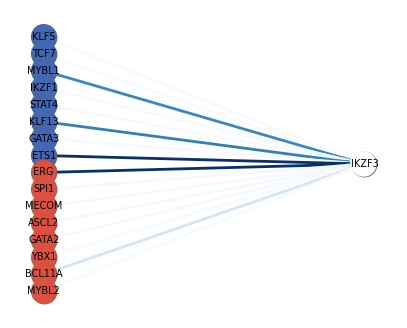

gene  IKZF3  run # 1


Epoch: 169, Loss: 0.07871992378072305: 100%|██| 170/170 [00:06<00:00, 25.03it/s]


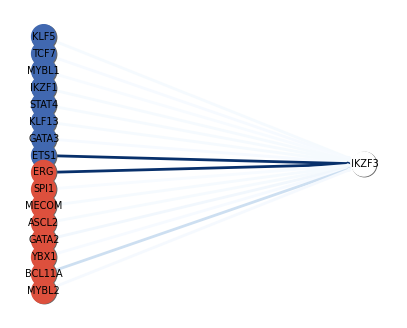

gene  IKZF3  run # 2


Epoch: 169, Loss: 0.09553887288678777: 100%|██| 170/170 [00:06<00:00, 25.10it/s]


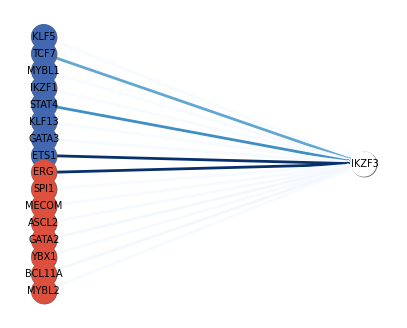

gene  IKZF3  run # 3


Epoch: 169, Loss: 0.1583415080200542: 100%|███| 170/170 [00:07<00:00, 24.19it/s]


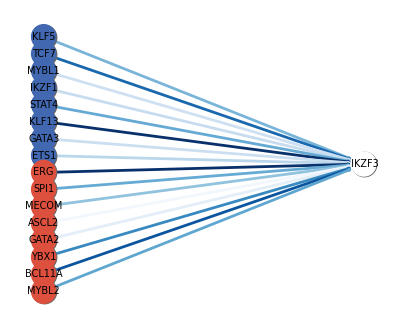

gene  IKZF3  run # 4


Epoch: 169, Loss: 0.09511875767599452: 100%|██| 170/170 [00:07<00:00, 24.21it/s]


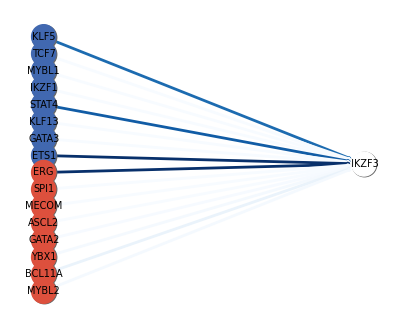

gene  IKZF3  run # 5


Epoch: 169, Loss: 0.08462932164018805: 100%|██| 170/170 [00:07<00:00, 23.95it/s]


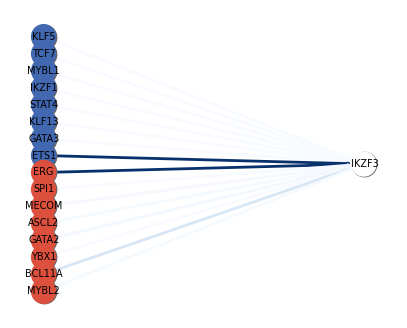

gene  IKZF3  run # 6


Epoch: 169, Loss: 0.09256581555713307: 100%|██| 170/170 [00:07<00:00, 23.21it/s]


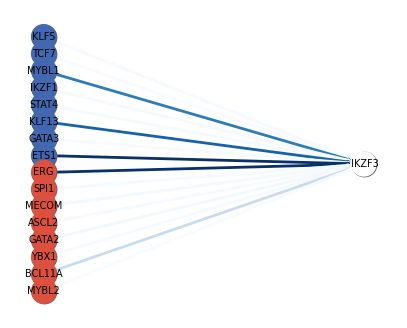

gene  IKZF3  run # 7


Epoch: 169, Loss: 0.11177634854208339: 100%|██| 170/170 [00:07<00:00, 24.00it/s]


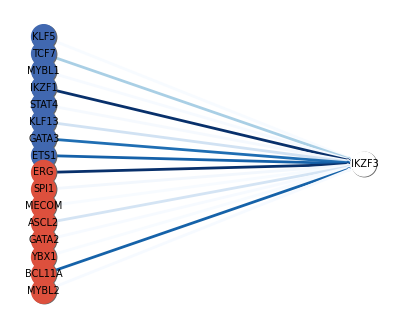

gene  IKZF3  run # 8


Epoch: 169, Loss: 0.09272666004571048: 100%|██| 170/170 [00:07<00:00, 23.93it/s]


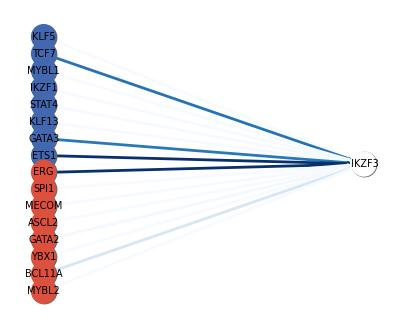

gene  IKZF3  run # 9


Epoch: 169, Loss: 0.08382943509654565: 100%|██| 170/170 [00:07<00:00, 23.95it/s]


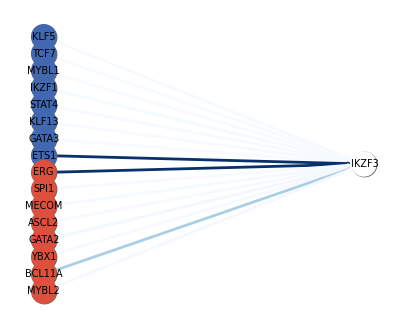

['ETS1'] ['ERG']
IKZF3 *= ( ETS1 ) and not (ERG )


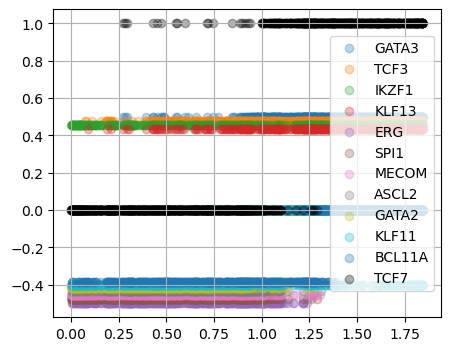

gene  TCF7  run # 0


Epoch: 169, Loss: 0.0456993928687139: 100%|███| 170/170 [00:07<00:00, 23.71it/s]


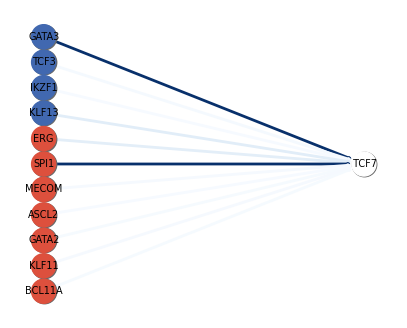

gene  TCF7  run # 1


Epoch: 169, Loss: 0.04504783485423435: 100%|██| 170/170 [00:07<00:00, 24.20it/s]


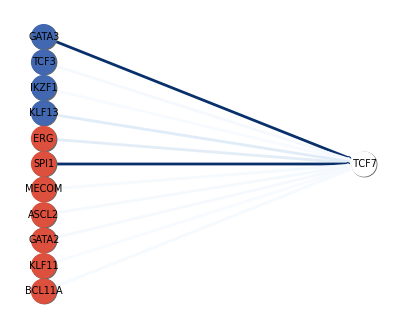

gene  TCF7  run # 2


Epoch: 169, Loss: 0.05815803564407609: 100%|██| 170/170 [00:07<00:00, 24.20it/s]


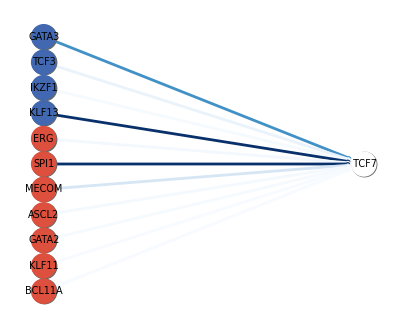

gene  TCF7  run # 3


Epoch: 169, Loss: 0.058773673393509605: 100%|█| 170/170 [00:06<00:00, 24.54it/s]


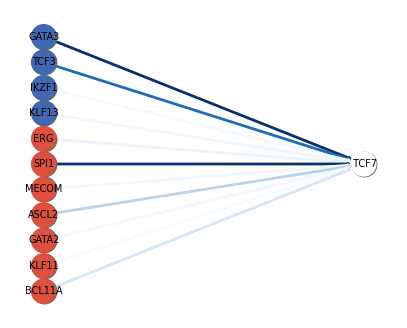

gene  TCF7  run # 4


Epoch: 169, Loss: 0.052351396192203865: 100%|█| 170/170 [00:07<00:00, 23.65it/s]


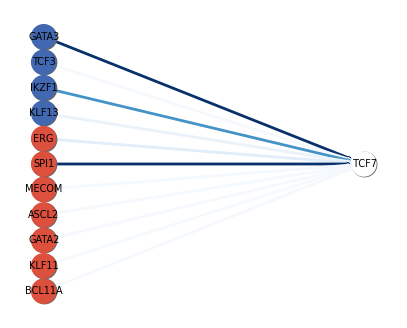

gene  TCF7  run # 5


Epoch: 169, Loss: 0.046202905137430535: 100%|█| 170/170 [00:06<00:00, 24.46it/s]


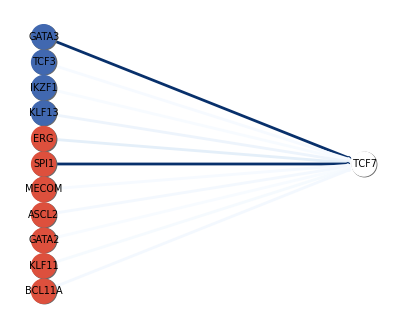

gene  TCF7  run # 6


Epoch: 169, Loss: 0.050446542487903076: 100%|█| 170/170 [00:06<00:00, 24.35it/s]


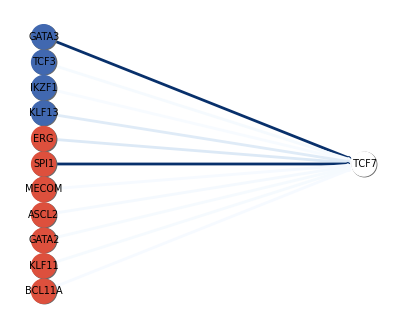

gene  TCF7  run # 7


Epoch: 169, Loss: 0.048288176682862366: 100%|█| 170/170 [00:06<00:00, 24.70it/s]


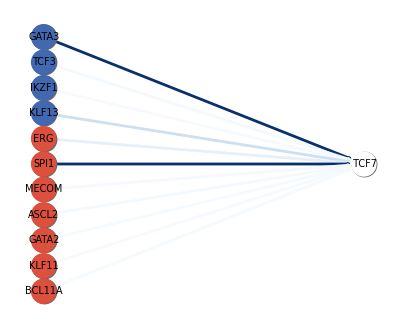

gene  TCF7  run # 8


Epoch: 169, Loss: 0.05041803622787649: 100%|██| 170/170 [00:06<00:00, 24.29it/s]


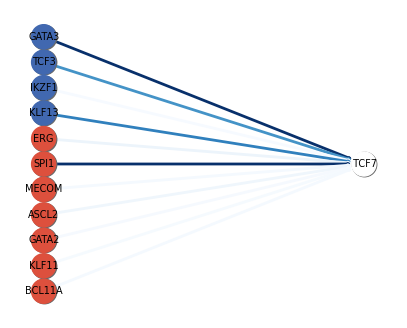

gene  TCF7  run # 9


Epoch: 169, Loss: 0.06082413548772985: 100%|██| 170/170 [00:06<00:00, 24.89it/s]


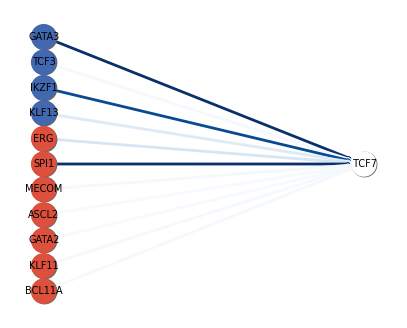

['GATA3'] ['SPI1']
TCF7 *= ( GATA3 ) and not (SPI1 )


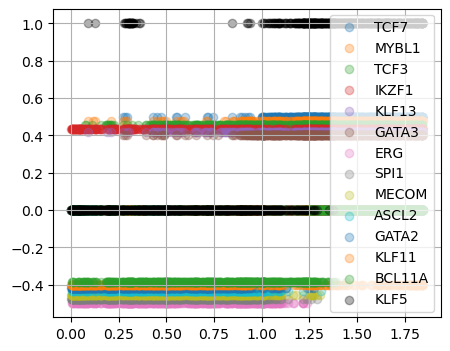

gene  KLF5  run # 0


Epoch: 169, Loss: 0.09452076662670482: 100%|██| 170/170 [00:06<00:00, 24.35it/s]


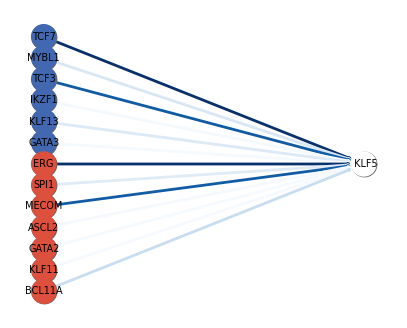

gene  KLF5  run # 1


Epoch: 169, Loss: 0.10449582202868028: 100%|██| 170/170 [00:06<00:00, 24.58it/s]


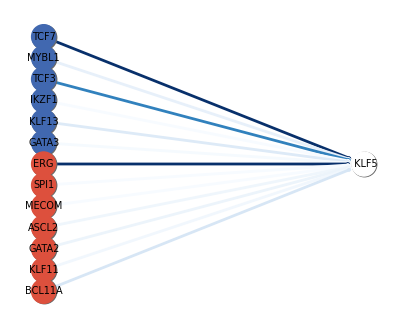

gene  KLF5  run # 2


Epoch: 169, Loss: 0.09829545021057129: 100%|██| 170/170 [00:06<00:00, 24.81it/s]


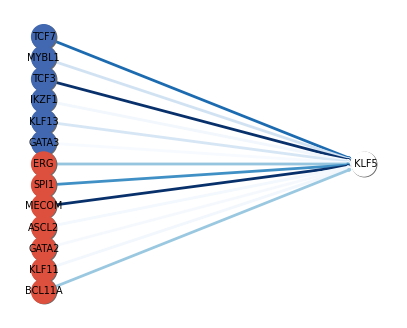

gene  KLF5  run # 3


Epoch: 169, Loss: 0.10156511786309155: 100%|██| 170/170 [00:07<00:00, 23.73it/s]


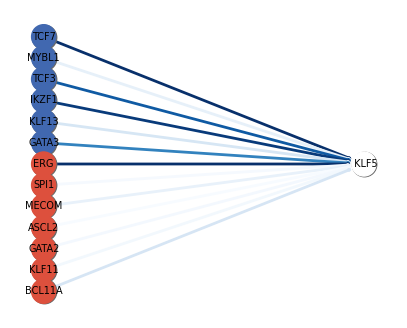

gene  KLF5  run # 4


Epoch: 169, Loss: 0.10029628737406297: 100%|██| 170/170 [00:06<00:00, 24.67it/s]


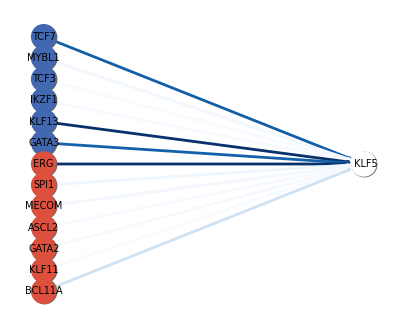

gene  KLF5  run # 5


Epoch: 169, Loss: 0.13022310828620737: 100%|██| 170/170 [00:06<00:00, 24.78it/s]


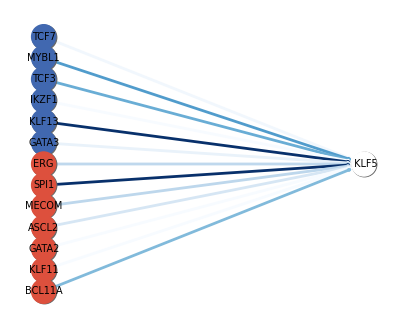

gene  KLF5  run # 6


Epoch: 169, Loss: 0.10122033140876076: 100%|██| 170/170 [00:06<00:00, 24.68it/s]


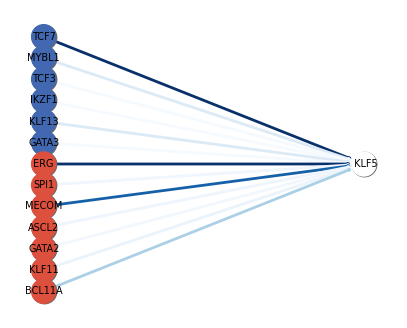

gene  KLF5  run # 7


Epoch: 169, Loss: 0.09192322600971568: 100%|██| 170/170 [00:06<00:00, 24.58it/s]


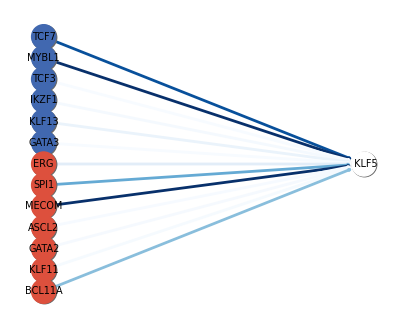

gene  KLF5  run # 8


Epoch: 169, Loss: 0.09996061975305731: 100%|██| 170/170 [00:06<00:00, 24.84it/s]


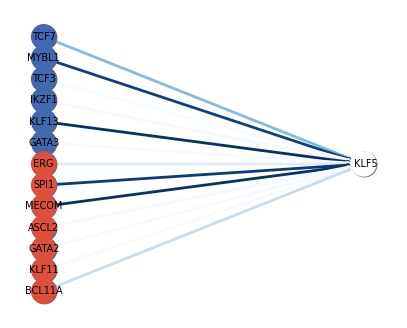

gene  KLF5  run # 9


Epoch: 169, Loss: 0.09213499420068481: 100%|██| 170/170 [00:06<00:00, 24.57it/s]


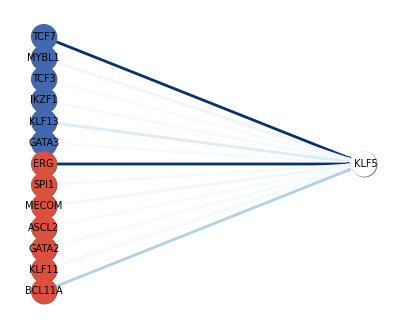

['TCF7'] ['ERG', 'BCL11A']
KLF5 *= ( TCF7 ) and not (ERG or BCL11A )


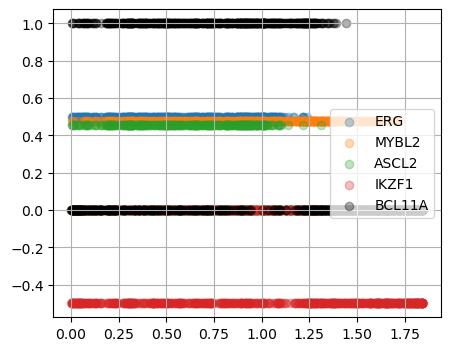

gene  BCL11A  run # 0


Epoch: 169, Loss: 0.144045390188694: 100%|████| 170/170 [00:06<00:00, 24.98it/s]


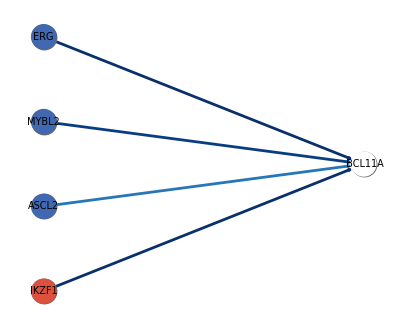

gene  BCL11A  run # 1


Epoch: 169, Loss: 0.12472143024206161: 100%|██| 170/170 [00:06<00:00, 25.02it/s]


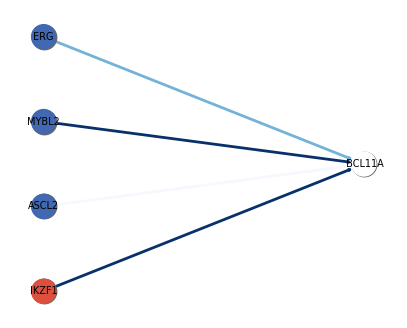

gene  BCL11A  run # 2


Epoch: 169, Loss: 0.1334654228253798: 100%|███| 170/170 [00:06<00:00, 24.67it/s]


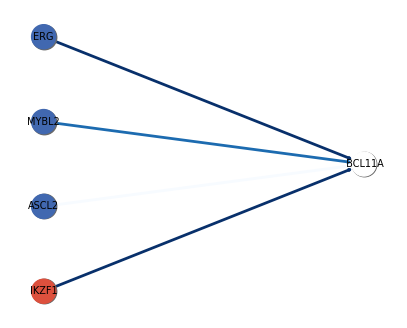

gene  BCL11A  run # 3


Epoch: 169, Loss: 0.1237560889937661: 100%|███| 170/170 [00:06<00:00, 24.92it/s]


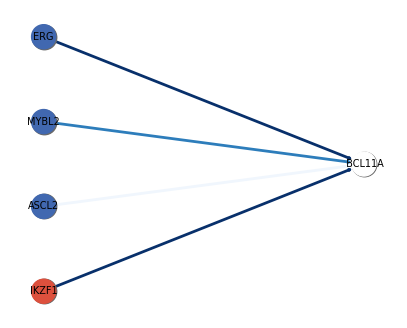

gene  BCL11A  run # 4


Epoch: 169, Loss: 0.13342434980652548: 100%|██| 170/170 [00:06<00:00, 24.64it/s]


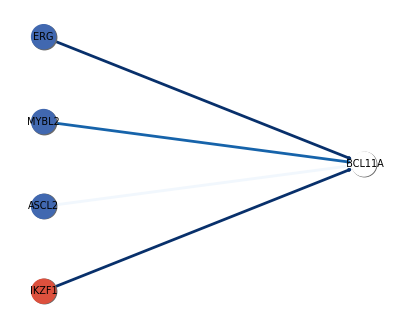

gene  BCL11A  run # 5


Epoch: 169, Loss: 0.13140515305779196: 100%|██| 170/170 [00:06<00:00, 24.35it/s]


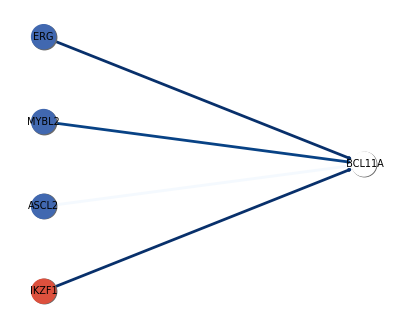

gene  BCL11A  run # 6


Epoch: 169, Loss: 0.13406077298251065: 100%|██| 170/170 [00:06<00:00, 24.44it/s]


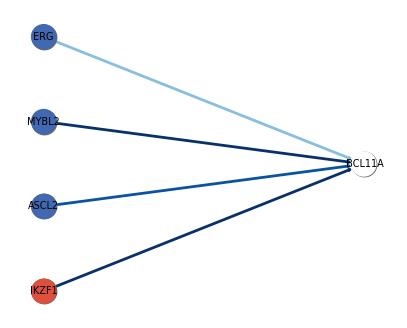

gene  BCL11A  run # 7


Epoch: 169, Loss: 0.13107812472365118: 100%|██| 170/170 [00:07<00:00, 24.13it/s]


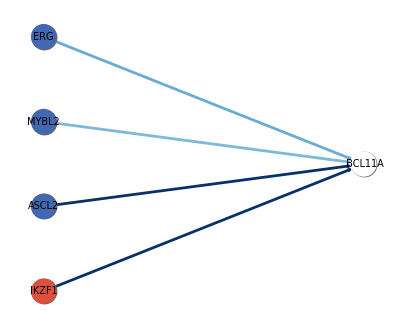

gene  BCL11A  run # 8


Epoch: 169, Loss: 0.1282566643574021: 100%|███| 170/170 [00:07<00:00, 23.85it/s]


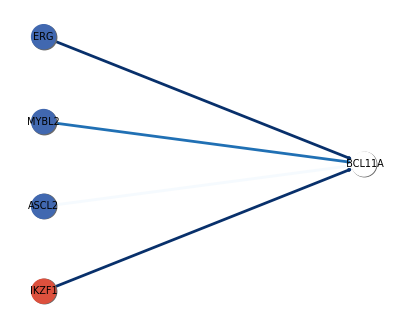

gene  BCL11A  run # 9


Epoch: 169, Loss: 0.13263394209471616: 100%|██| 170/170 [00:07<00:00, 24.22it/s]


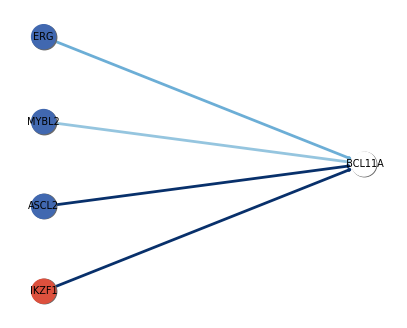

['ERG', 'MYBL2'] ['IKZF1']
BCL11A *= ( ERG and MYBL2 ) and not (IKZF1 )


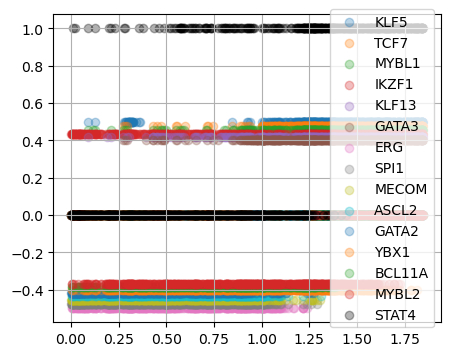

gene  STAT4  run # 0


Epoch: 169, Loss: 0.10891286351464012: 100%|██| 170/170 [00:07<00:00, 23.89it/s]


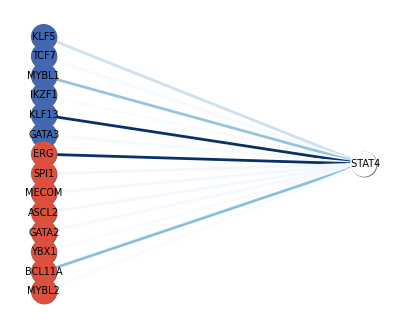

gene  STAT4  run # 1


Epoch: 169, Loss: 0.11666140163486655: 100%|██| 170/170 [00:07<00:00, 23.47it/s]


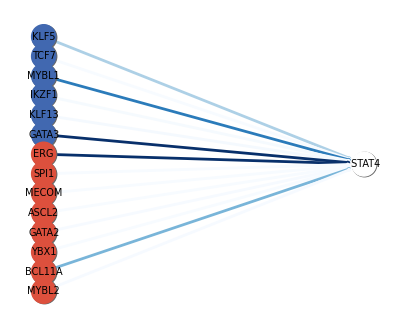

gene  STAT4  run # 2


Epoch: 169, Loss: 0.11212830651890147: 100%|██| 170/170 [00:07<00:00, 23.98it/s]


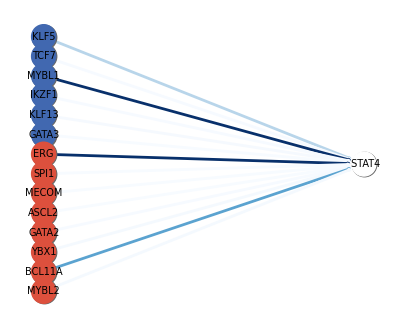

gene  STAT4  run # 3


Epoch: 169, Loss: 0.11535819348963824: 100%|██| 170/170 [00:07<00:00, 24.27it/s]


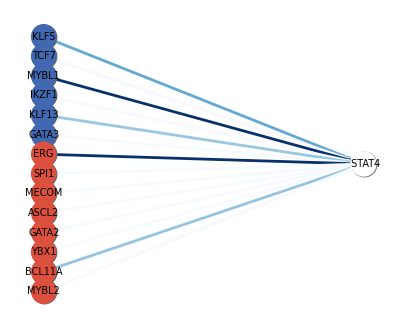

gene  STAT4  run # 4


Epoch: 169, Loss: 0.10606395588679747: 100%|██| 170/170 [00:06<00:00, 24.49it/s]


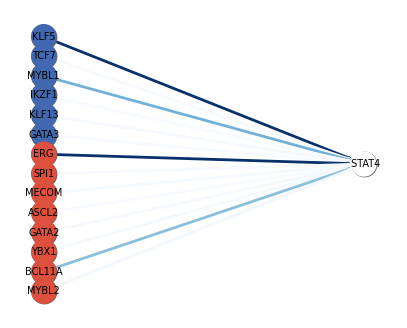

gene  STAT4  run # 5


Epoch: 169, Loss: 0.12080166963013736: 100%|██| 170/170 [00:07<00:00, 23.19it/s]


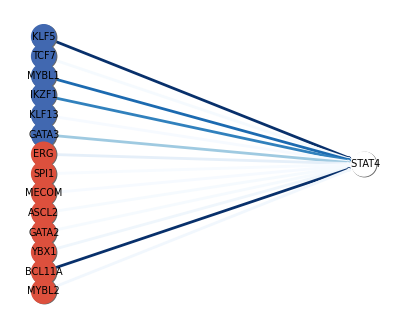

gene  STAT4  run # 6


Epoch: 169, Loss: 0.11553962596438148: 100%|██| 170/170 [00:06<00:00, 24.36it/s]


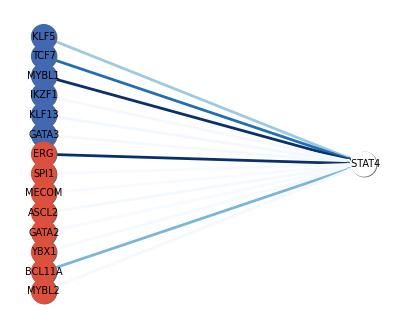

gene  STAT4  run # 7


Epoch: 169, Loss: 0.11462854526259682: 100%|██| 170/170 [00:06<00:00, 24.61it/s]


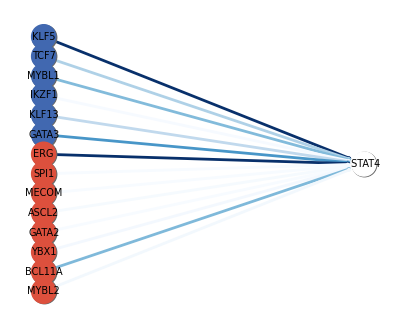

gene  STAT4  run # 8


Epoch: 169, Loss: 0.10924385555765846: 100%|██| 170/170 [00:06<00:00, 24.59it/s]


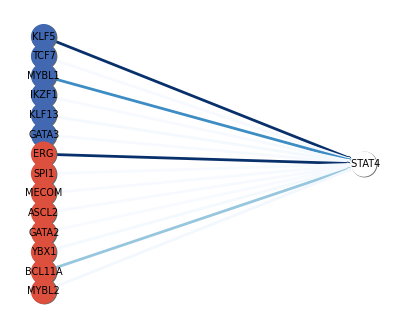

gene  STAT4  run # 9


Epoch: 169, Loss: 0.11013318395072763: 100%|██| 170/170 [00:06<00:00, 24.50it/s]


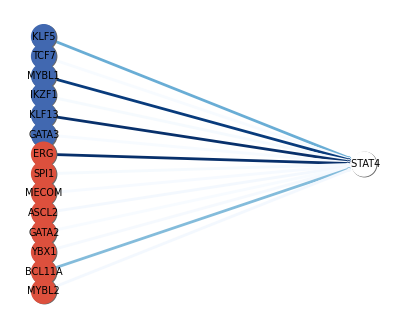

['KLF5', 'MYBL1'] ['ERG', 'BCL11A']
STAT4 *= ( KLF5 and MYBL1 ) and not (ERG or BCL11A )


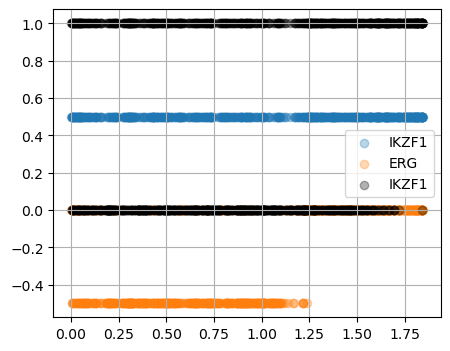

gene  IKZF1  run # 0


Epoch: 169, Loss: 0.008951537565074184: 100%|█| 170/170 [00:06<00:00, 24.79it/s]


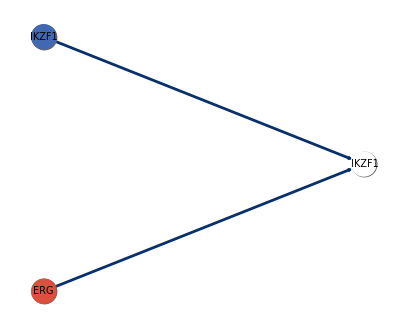

gene  IKZF1  run # 1


Epoch: 169, Loss: 0.008955092677338556: 100%|█| 170/170 [00:06<00:00, 24.61it/s]


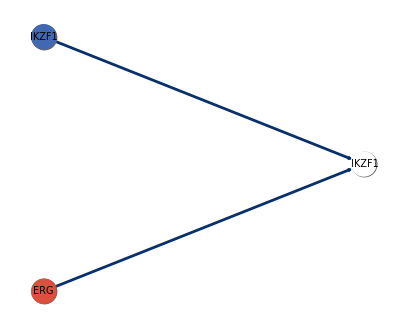

gene  IKZF1  run # 2


Epoch: 169, Loss: 0.009066109968857332: 100%|█| 170/170 [00:06<00:00, 25.37it/s]


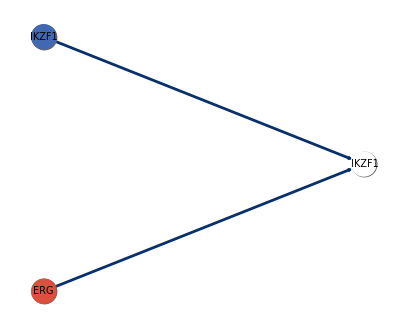

gene  IKZF1  run # 3


Epoch: 169, Loss: 0.008957780728285963: 100%|█| 170/170 [00:06<00:00, 25.01it/s]


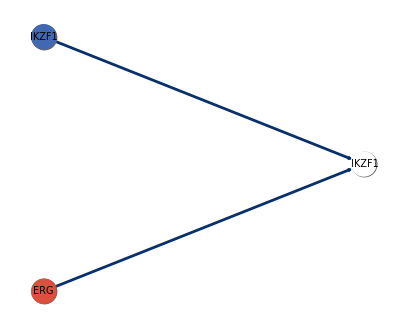

gene  IKZF1  run # 4


Epoch: 169, Loss: 0.008954360403797844: 100%|█| 170/170 [00:06<00:00, 24.72it/s]


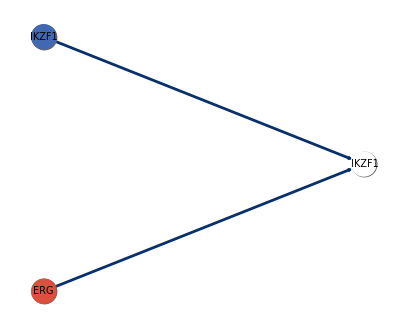

gene  IKZF1  run # 5


Epoch: 169, Loss: 0.008957619440149178: 100%|█| 170/170 [00:06<00:00, 25.32it/s]


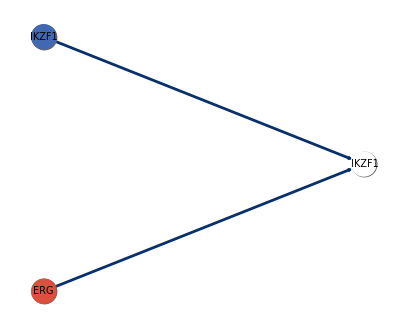

gene  IKZF1  run # 6


Epoch: 169, Loss: 0.009055027399550785: 100%|█| 170/170 [00:07<00:00, 24.28it/s]


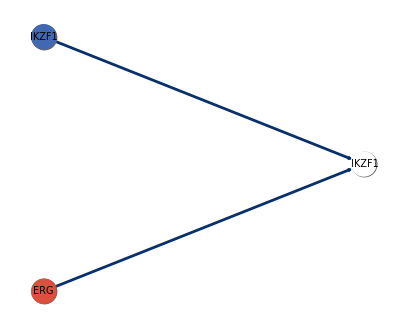

gene  IKZF1  run # 7


Epoch: 169, Loss: 0.008960738270120188: 100%|█| 170/170 [00:06<00:00, 24.97it/s]


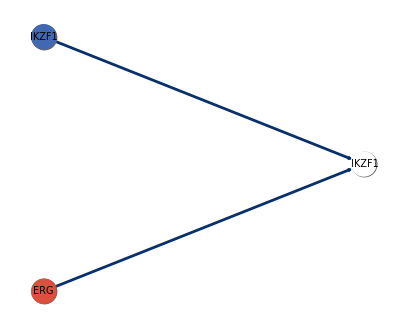

gene  IKZF1  run # 8


Epoch: 169, Loss: 0.008958311751484871: 100%|█| 170/170 [00:06<00:00, 24.79it/s]


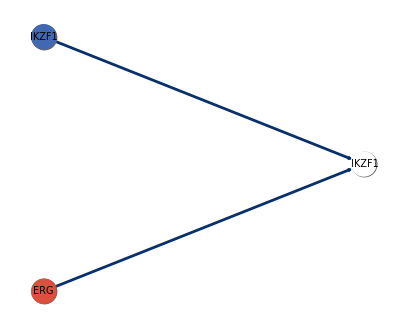

gene  IKZF1  run # 9


Epoch: 169, Loss: 0.008954837664284489: 100%|█| 170/170 [00:06<00:00, 25.16it/s]


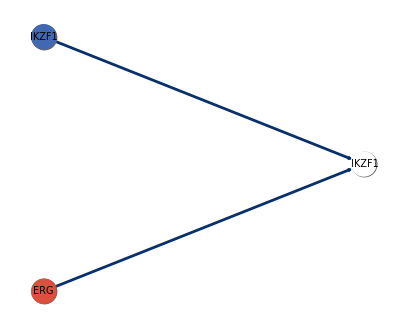

['IKZF1'] ['ERG']
IKZF1 *= ( IKZF1 ) and not (ERG )


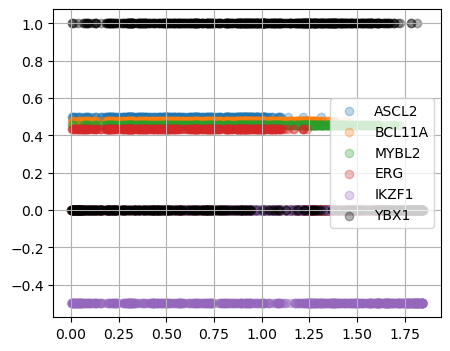

gene  YBX1  run # 0


Epoch: 169, Loss: 0.06603470681743188: 100%|██| 170/170 [00:06<00:00, 24.81it/s]


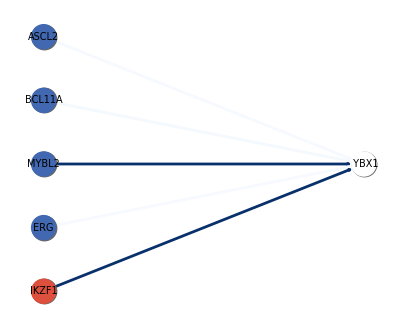

gene  YBX1  run # 1


Epoch: 169, Loss: 0.08469945971261371: 100%|██| 170/170 [00:06<00:00, 24.93it/s]


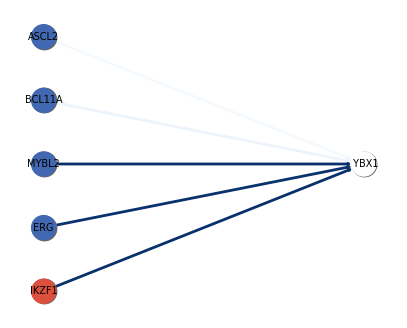

gene  YBX1  run # 2


Epoch: 169, Loss: 0.07555036957968365: 100%|██| 170/170 [00:06<00:00, 24.32it/s]


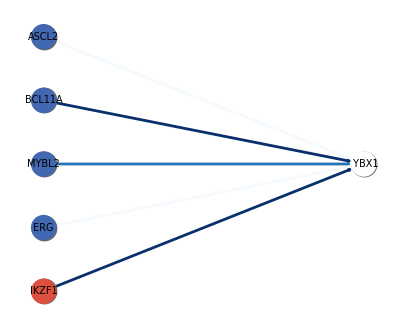

gene  YBX1  run # 3


Epoch: 169, Loss: 0.07530055736953561: 100%|██| 170/170 [00:07<00:00, 23.18it/s]


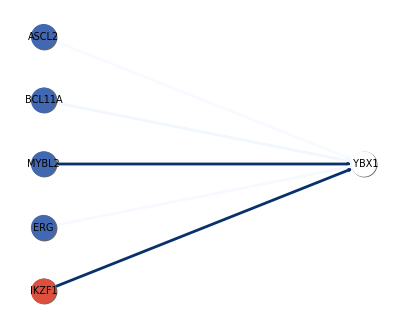

gene  YBX1  run # 4


Epoch: 169, Loss: 0.08099142665212805: 100%|██| 170/170 [00:06<00:00, 24.91it/s]


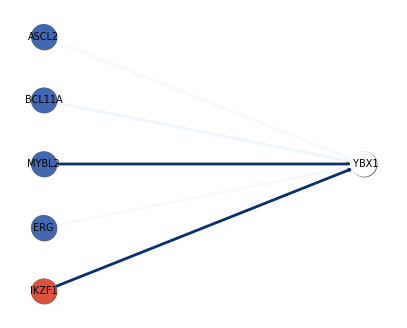

gene  YBX1  run # 5


Epoch: 169, Loss: 0.07258048789067702: 100%|██| 170/170 [00:06<00:00, 24.93it/s]


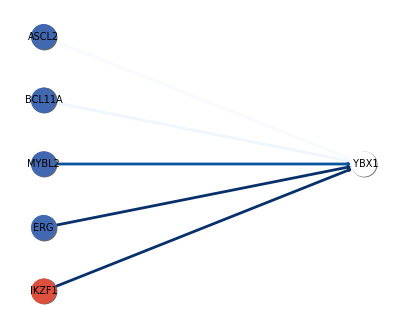

gene  YBX1  run # 6


Epoch: 169, Loss: 0.12060255625031212: 100%|██| 170/170 [00:06<00:00, 24.80it/s]


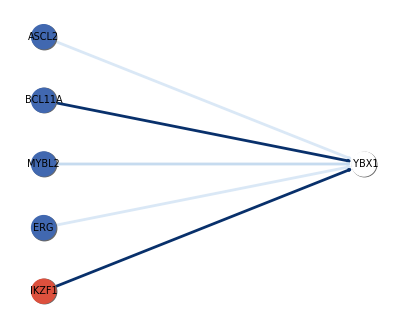

gene  YBX1  run # 7


Epoch: 169, Loss: 0.0803055888549848: 100%|███| 170/170 [00:07<00:00, 22.61it/s]


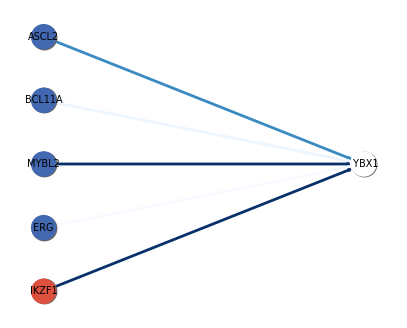

gene  YBX1  run # 8


Epoch: 169, Loss: 0.07404448464512825: 100%|██| 170/170 [00:07<00:00, 22.67it/s]


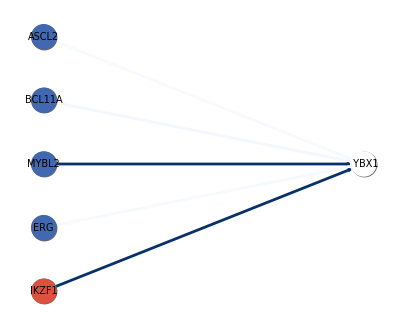

gene  YBX1  run # 9


Epoch: 169, Loss: 0.08022185144099322: 100%|██| 170/170 [00:07<00:00, 23.83it/s]


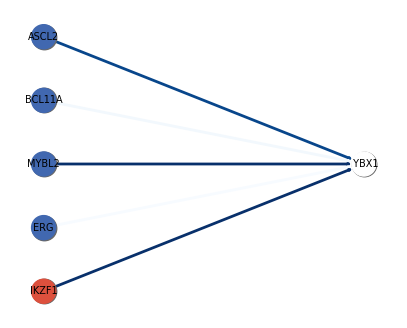

['MYBL2'] ['IKZF1']
YBX1 *= ( MYBL2 ) and not (IKZF1 )


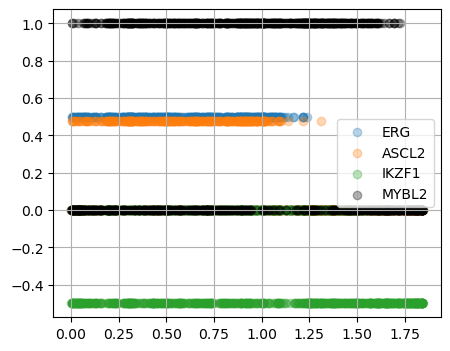

gene  MYBL2  run # 0


Epoch: 169, Loss: 0.18142616748809814: 100%|██| 170/170 [00:07<00:00, 22.60it/s]


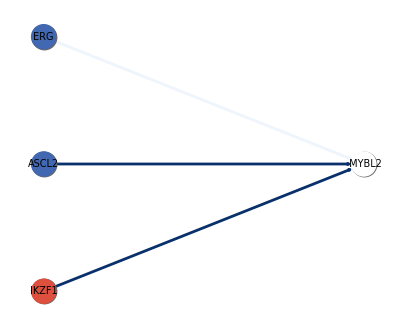

gene  MYBL2  run # 1


Epoch: 169, Loss: 0.17780876566063275: 100%|██| 170/170 [00:07<00:00, 23.10it/s]


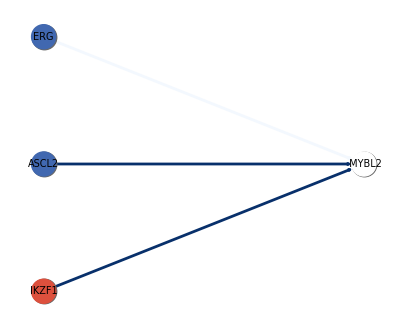

gene  MYBL2  run # 2


Epoch: 169, Loss: 0.17358258231119675: 100%|██| 170/170 [00:07<00:00, 22.80it/s]


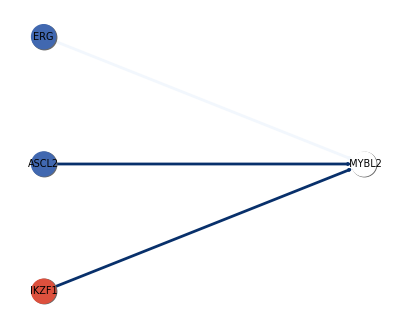

gene  MYBL2  run # 3


Epoch: 169, Loss: 0.18344852328300476: 100%|██| 170/170 [00:08<00:00, 19.79it/s]


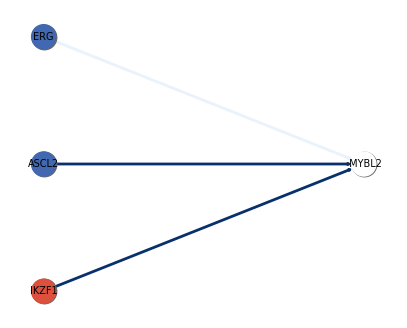

gene  MYBL2  run # 4


Epoch: 169, Loss: 0.17617474496364594: 100%|██| 170/170 [00:07<00:00, 22.20it/s]


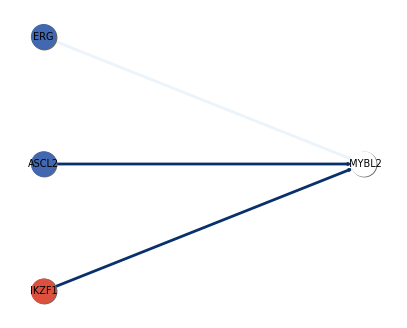

gene  MYBL2  run # 5


Epoch: 169, Loss: 0.18263856253840707: 100%|██| 170/170 [00:07<00:00, 22.71it/s]


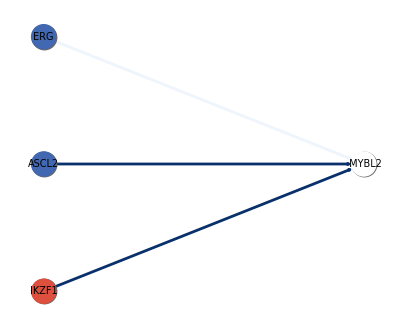

gene  MYBL2  run # 6


Epoch: 169, Loss: 0.18038091334429654: 100%|██| 170/170 [00:07<00:00, 22.92it/s]


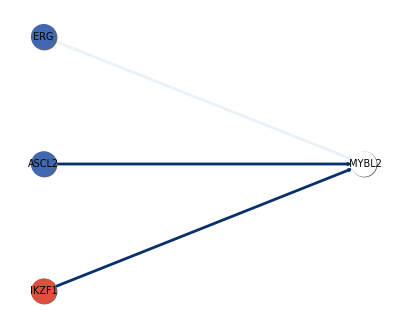

gene  MYBL2  run # 7


Epoch: 169, Loss: 0.2083079286596992: 100%|███| 170/170 [00:07<00:00, 22.01it/s]


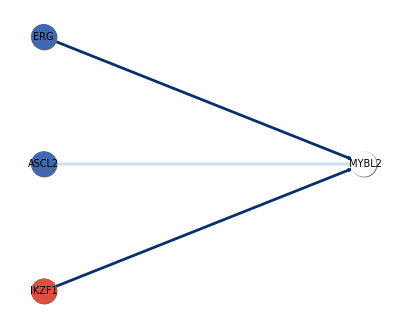

gene  MYBL2  run # 8


Epoch: 169, Loss: 0.18775725229219956: 100%|██| 170/170 [00:07<00:00, 22.80it/s]


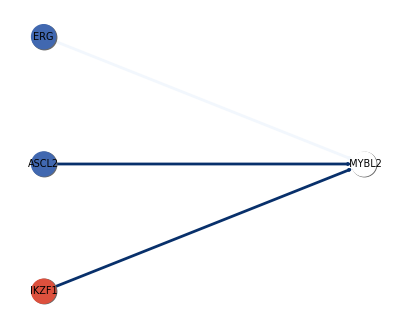

gene  MYBL2  run # 9


Epoch: 169, Loss: 0.17351531846956772: 100%|██| 170/170 [00:07<00:00, 22.44it/s]


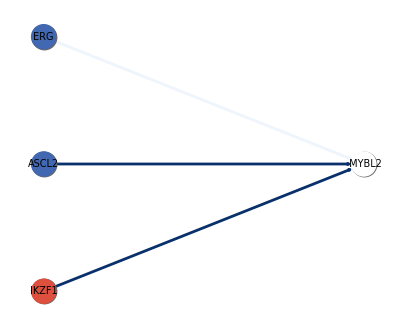

['ASCL2'] ['IKZF1']
MYBL2 *= ( ASCL2 ) and not (IKZF1 )


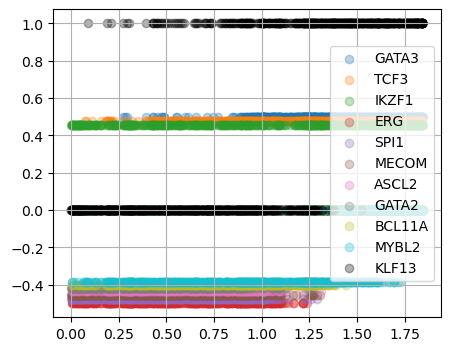

gene  KLF13  run # 0


Epoch: 169, Loss: 0.12926785918799313: 100%|██| 170/170 [00:07<00:00, 23.12it/s]


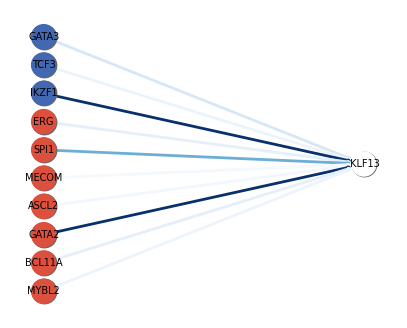

gene  KLF13  run # 1


Epoch: 169, Loss: 0.12334831871769646: 100%|██| 170/170 [00:07<00:00, 22.84it/s]


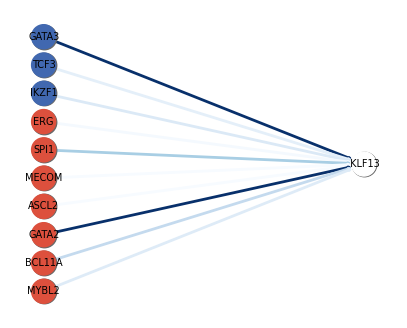

gene  KLF13  run # 2


Epoch: 169, Loss: 0.12123206867413087: 100%|██| 170/170 [00:07<00:00, 23.13it/s]


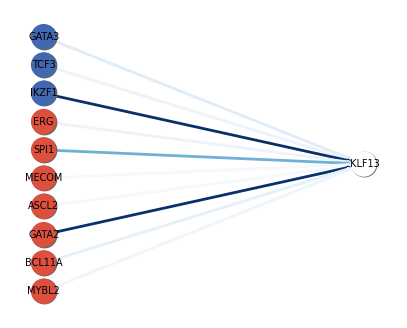

gene  KLF13  run # 3


Epoch: 169, Loss: 0.12257793952118266: 100%|██| 170/170 [00:08<00:00, 19.47it/s]


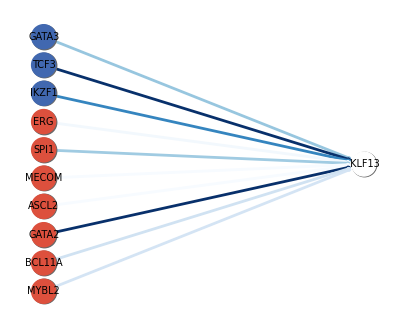

gene  KLF13  run # 4


Epoch: 169, Loss: 0.11316724257035689: 100%|██| 170/170 [00:08<00:00, 20.07it/s]


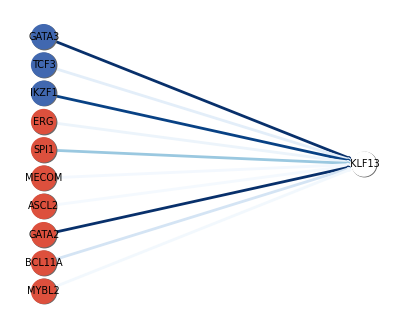

gene  KLF13  run # 5


Epoch: 169, Loss: 0.112800426103852: 100%|████| 170/170 [00:08<00:00, 20.43it/s]


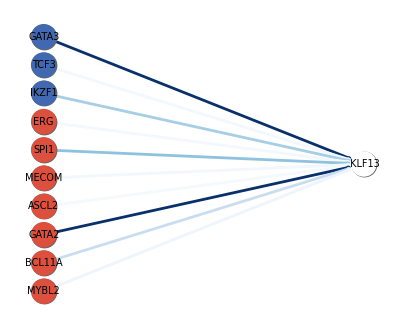

gene  KLF13  run # 6


Epoch: 169, Loss: 0.11820799992843108: 100%|██| 170/170 [00:08<00:00, 21.24it/s]


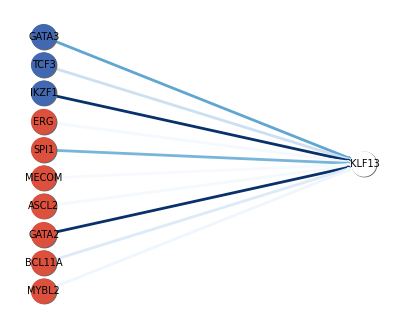

gene  KLF13  run # 7


Epoch: 169, Loss: 0.123558563942259: 100%|████| 170/170 [00:07<00:00, 22.45it/s]


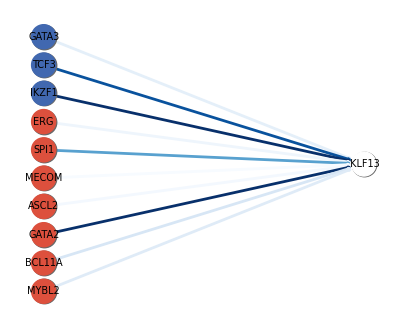

gene  KLF13  run # 8


Epoch: 169, Loss: 0.11023666912859137: 100%|██| 170/170 [00:07<00:00, 23.08it/s]


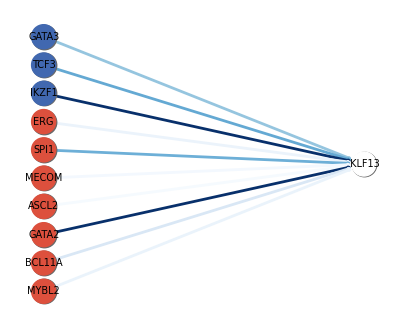

gene  KLF13  run # 9


Epoch: 169, Loss: 0.12259237197312442: 100%|██| 170/170 [00:07<00:00, 21.50it/s]


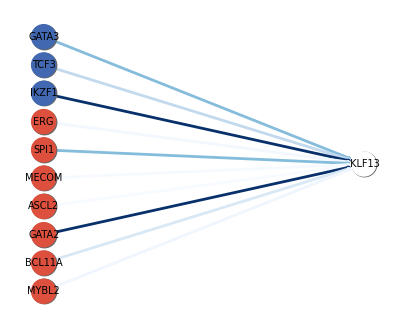

['IKZF1'] ['SPI1', 'GATA2']
KLF13 *= ( IKZF1 ) and not (SPI1 or GATA2 )


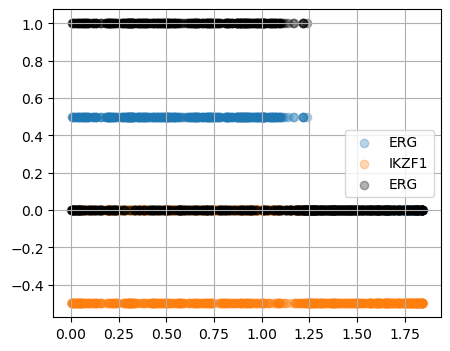

gene  ERG  run # 0


Epoch: 169, Loss: 0.008984805931421843: 100%|█| 170/170 [00:06<00:00, 24.97it/s]


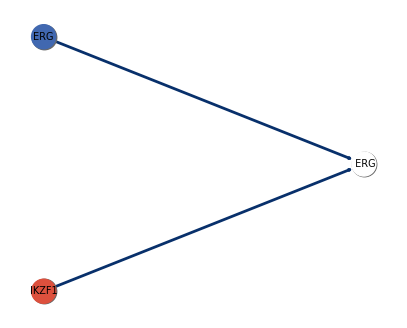

gene  ERG  run # 1


Epoch: 169, Loss: 0.008988478390330618: 100%|█| 170/170 [00:07<00:00, 21.88it/s]


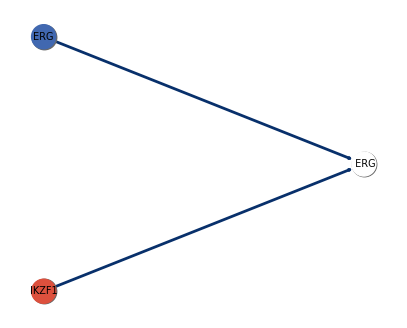

gene  ERG  run # 2


Epoch: 169, Loss: 0.009086601436138153: 100%|█| 170/170 [00:07<00:00, 24.05it/s]


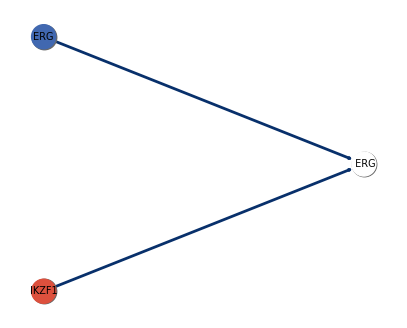

gene  ERG  run # 3


Epoch: 169, Loss: 0.008989919315684925: 100%|█| 170/170 [00:07<00:00, 23.13it/s]


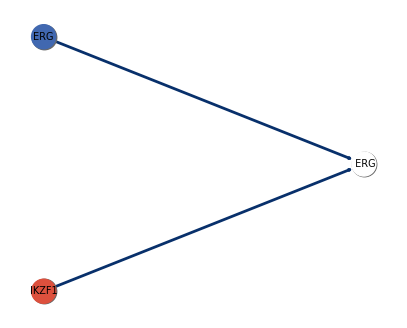

gene  ERG  run # 4


Epoch: 169, Loss: 0.008989714255387133: 100%|█| 170/170 [00:07<00:00, 24.21it/s]


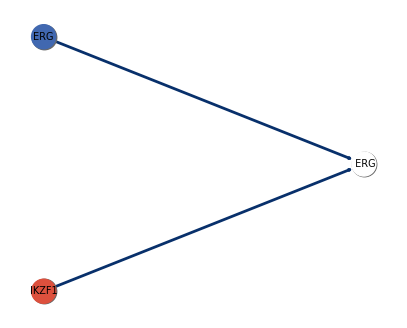

gene  ERG  run # 5


Epoch: 169, Loss: 0.008989749052985148: 100%|█| 170/170 [00:07<00:00, 23.47it/s]


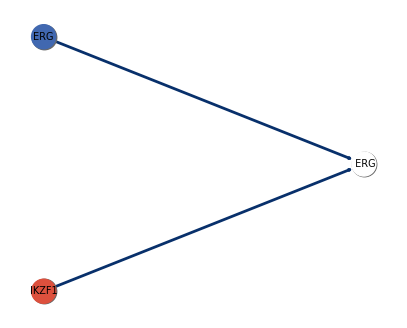

gene  ERG  run # 6


Epoch: 169, Loss: 0.008997164158658548: 100%|█| 170/170 [00:07<00:00, 23.23it/s]


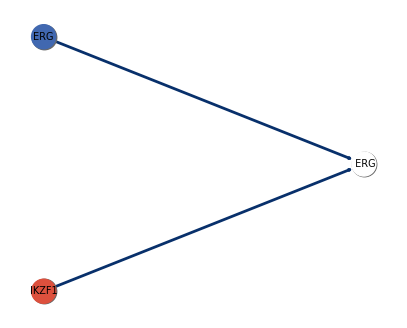

gene  ERG  run # 7


Epoch: 169, Loss: 0.009079268879511139: 100%|█| 170/170 [00:07<00:00, 23.21it/s]


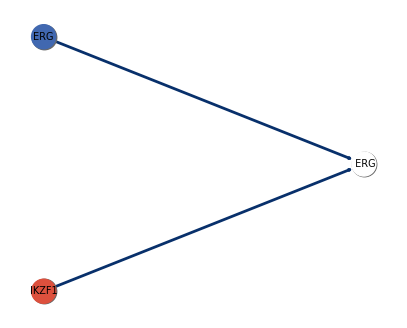

gene  ERG  run # 8


Epoch: 169, Loss: 0.00899218920279633: 100%|██| 170/170 [00:07<00:00, 23.12it/s]


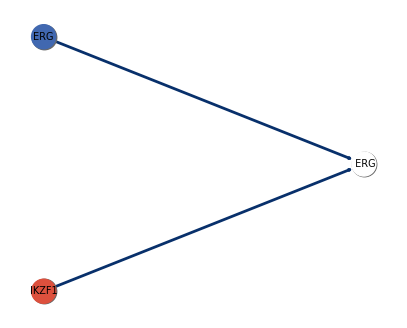

gene  ERG  run # 9


Epoch: 169, Loss: 0.008985042656687174: 100%|█| 170/170 [00:07<00:00, 23.70it/s]


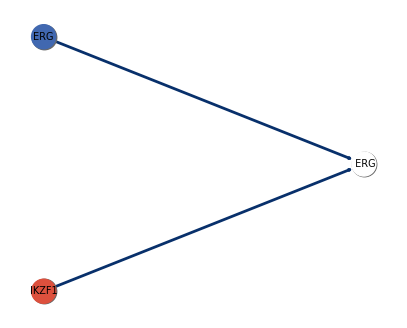

['ERG'] ['IKZF1']
ERG *= ( ERG ) and not (IKZF1 )


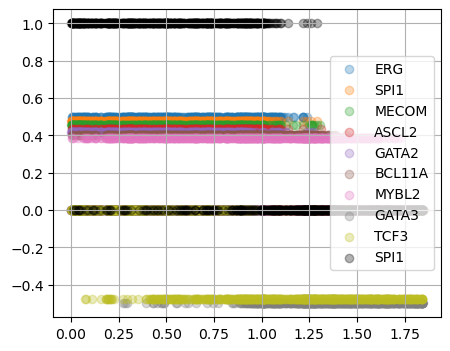

gene  SPI1  run # 0


Epoch: 169, Loss: 0.0342725200409239: 100%|███| 170/170 [00:07<00:00, 23.11it/s]


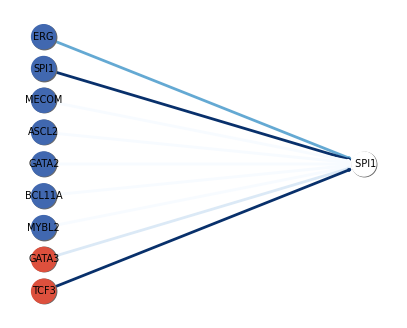

gene  SPI1  run # 1


Epoch: 169, Loss: 0.04623495719649575: 100%|██| 170/170 [00:06<00:00, 25.64it/s]


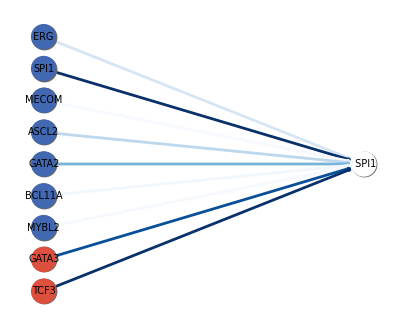

gene  SPI1  run # 2


Epoch: 169, Loss: 0.03591878644444726: 100%|██| 170/170 [00:08<00:00, 21.13it/s]


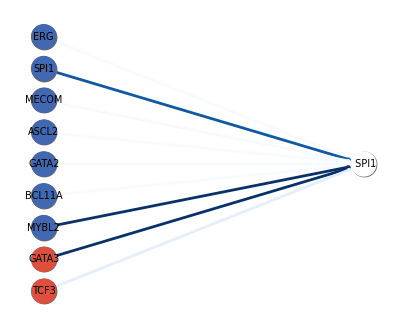

gene  SPI1  run # 3


Epoch: 169, Loss: 0.028911573812365532: 100%|█| 170/170 [00:06<00:00, 25.12it/s]


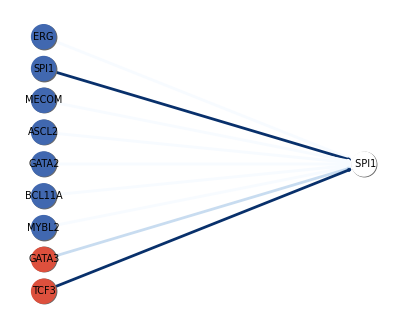

gene  SPI1  run # 4


Epoch: 169, Loss: 0.03586702658371492: 100%|██| 170/170 [00:06<00:00, 24.30it/s]


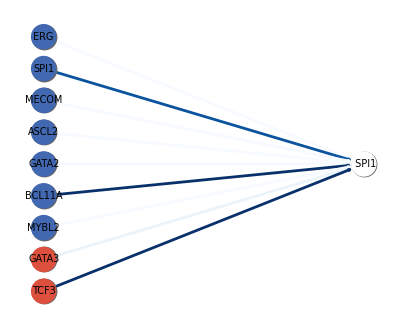

gene  SPI1  run # 5


Epoch: 169, Loss: 0.040814337743954224: 100%|█| 170/170 [00:07<00:00, 24.08it/s]


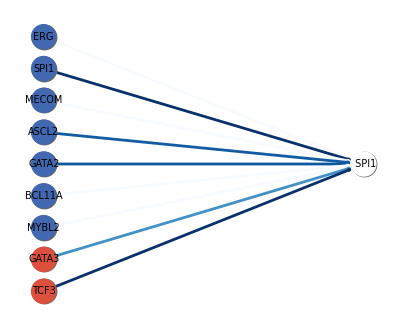

gene  SPI1  run # 6


Epoch: 169, Loss: 0.08944779499010606: 100%|██| 170/170 [00:11<00:00, 15.04it/s]


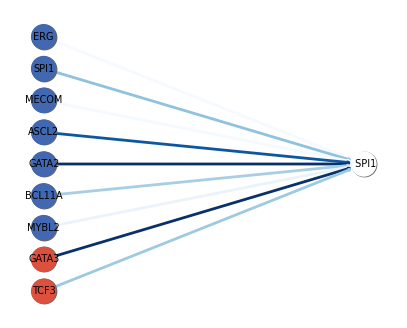

gene  SPI1  run # 7


Epoch: 169, Loss: 0.11121798984029076: 100%|██| 170/170 [00:08<00:00, 20.39it/s]


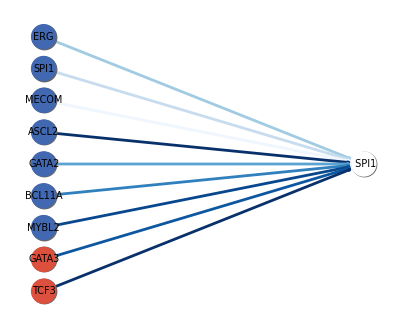

gene  SPI1  run # 8


Epoch: 169, Loss: 0.02950174683196978: 100%|██| 170/170 [00:07<00:00, 22.53it/s]


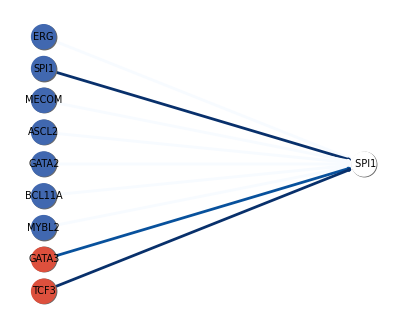

gene  SPI1  run # 9


Epoch: 169, Loss: 0.040018981491977516: 100%|█| 170/170 [00:07<00:00, 22.74it/s]


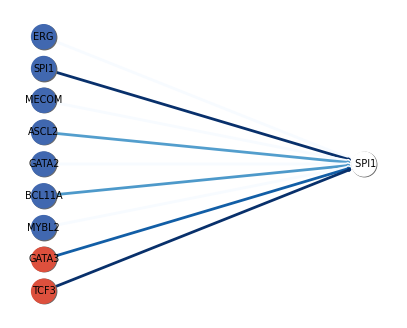

['SPI1'] ['GATA3', 'TCF3']
SPI1 *= ( SPI1 ) and not (GATA3 or TCF3 )


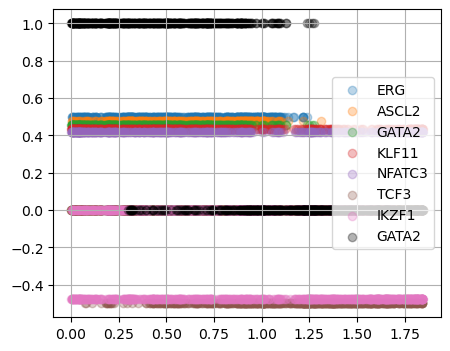

gene  GATA2  run # 0


Epoch: 169, Loss: 0.027866233478892933: 100%|█| 170/170 [00:06<00:00, 25.55it/s]


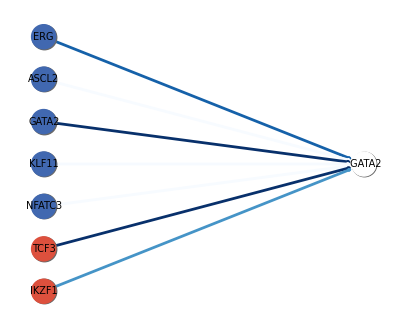

gene  GATA2  run # 1


Epoch: 169, Loss: 0.028449821709231896: 100%|█| 170/170 [00:06<00:00, 25.44it/s]


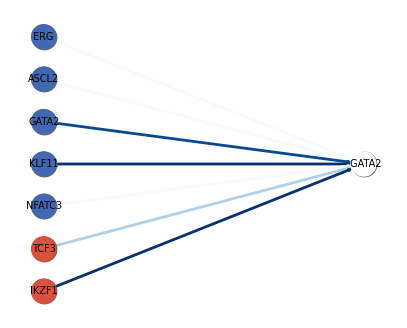

gene  GATA2  run # 2


Epoch: 169, Loss: 0.022281908176162026: 100%|█| 170/170 [00:07<00:00, 23.75it/s]


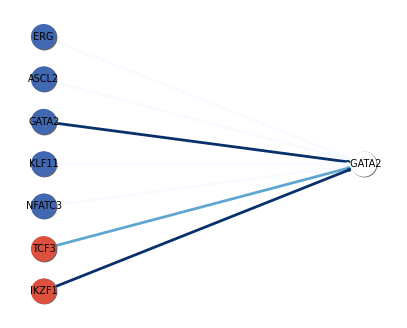

gene  GATA2  run # 3


Epoch: 169, Loss: 0.04334828562357209: 100%|██| 170/170 [00:08<00:00, 21.22it/s]


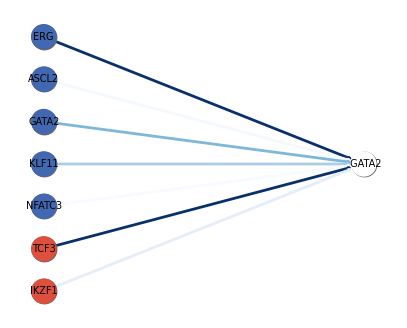

gene  GATA2  run # 4


Epoch: 169, Loss: 0.022485430098392746: 100%|█| 170/170 [00:07<00:00, 21.45it/s]


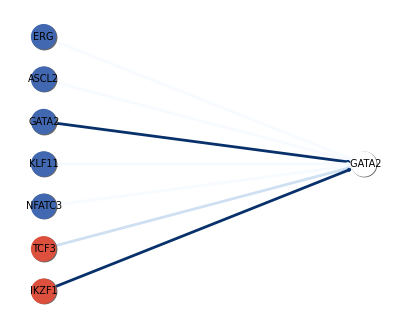

gene  GATA2  run # 5


Epoch: 169, Loss: 0.027750996872782707: 100%|█| 170/170 [00:07<00:00, 22.42it/s]


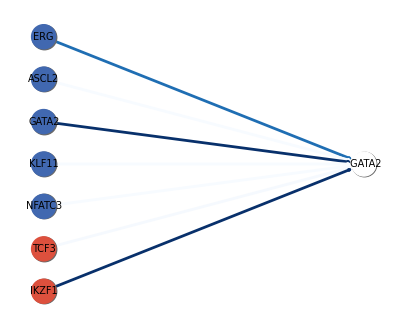

gene  GATA2  run # 6


Epoch: 169, Loss: 0.02751593647355383: 100%|██| 170/170 [00:07<00:00, 22.09it/s]


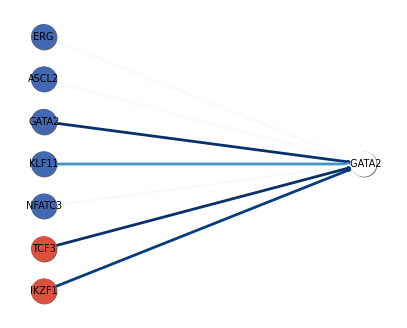

gene  GATA2  run # 7


Epoch: 169, Loss: 0.02735430323942141: 100%|██| 170/170 [00:06<00:00, 25.54it/s]


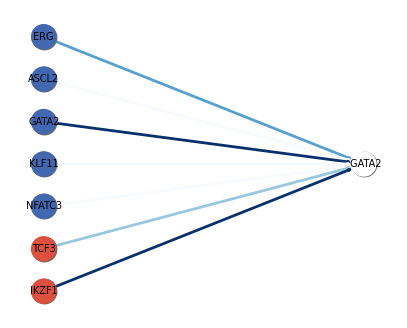

gene  GATA2  run # 8


Epoch: 169, Loss: 0.027106908573345703: 100%|█| 170/170 [00:07<00:00, 21.47it/s]


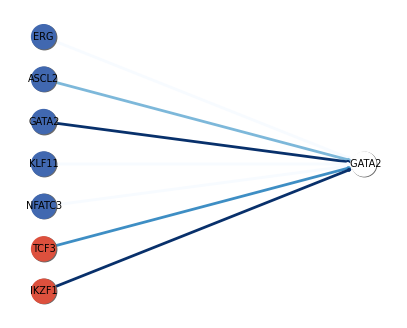

gene  GATA2  run # 9


Epoch: 169, Loss: 0.030307519842277874: 100%|█| 170/170 [00:07<00:00, 21.35it/s]


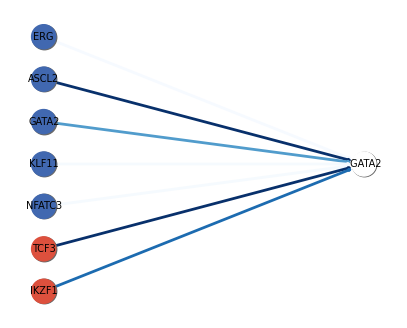

['GATA2'] ['TCF3', 'IKZF1']
GATA2 *= ( GATA2 ) and not (TCF3 or IKZF1 )


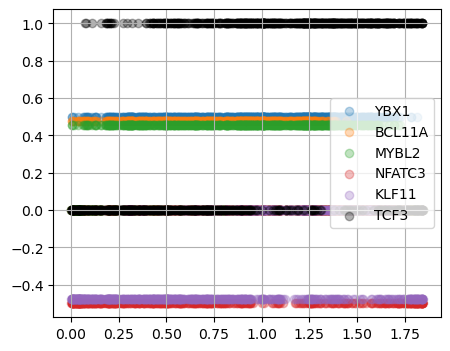

gene  TCF3  run # 0


Epoch: 169, Loss: 0.17020178924907337: 100%|██| 170/170 [00:08<00:00, 20.83it/s]


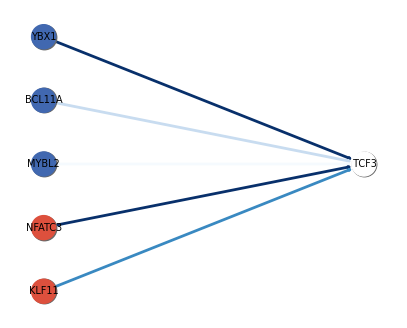

gene  TCF3  run # 1


Epoch: 169, Loss: 0.17781043323603543: 100%|██| 170/170 [00:07<00:00, 23.61it/s]


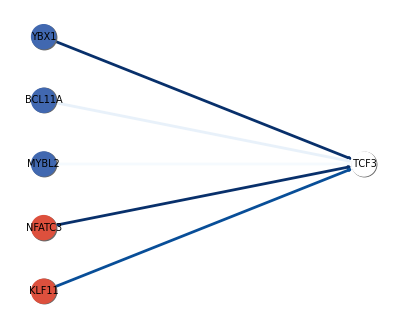

gene  TCF3  run # 2


Epoch: 169, Loss: 0.16868174753405832: 100%|██| 170/170 [00:07<00:00, 22.07it/s]


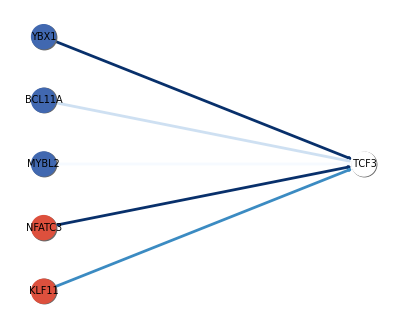

gene  TCF3  run # 3


Epoch: 169, Loss: 0.1679861071434888: 100%|███| 170/170 [00:07<00:00, 22.37it/s]


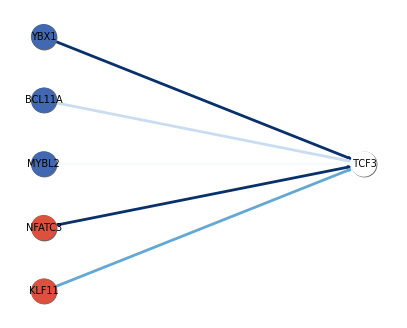

gene  TCF3  run # 4


Epoch: 169, Loss: 0.16918731684034521: 100%|██| 170/170 [00:07<00:00, 23.13it/s]


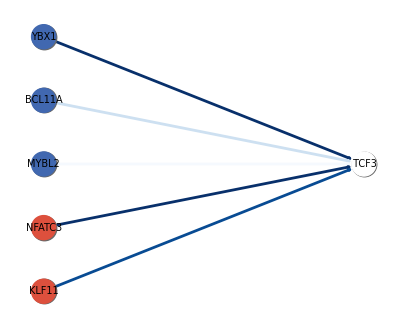

gene  TCF3  run # 5


Epoch: 169, Loss: 0.18494910137219864: 100%|██| 170/170 [00:07<00:00, 22.86it/s]


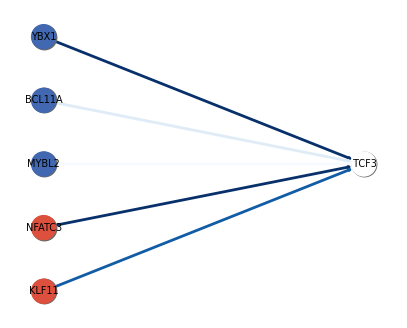

gene  TCF3  run # 6


Epoch: 169, Loss: 0.17699660225348038: 100%|██| 170/170 [00:08<00:00, 19.33it/s]


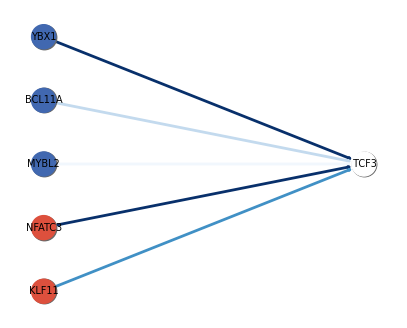

gene  TCF3  run # 7


Epoch: 169, Loss: 0.2159683880480853: 100%|███| 170/170 [00:06<00:00, 24.34it/s]


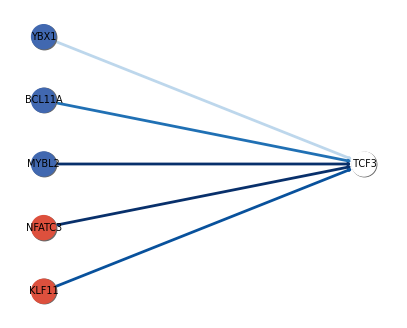

gene  TCF3  run # 8


Epoch: 169, Loss: 0.1832598176869479: 100%|███| 170/170 [00:06<00:00, 25.18it/s]


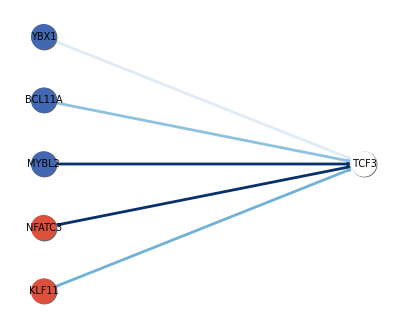

gene  TCF3  run # 9


Epoch: 169, Loss: 0.17630145089192825: 100%|██| 170/170 [00:08<00:00, 20.29it/s]


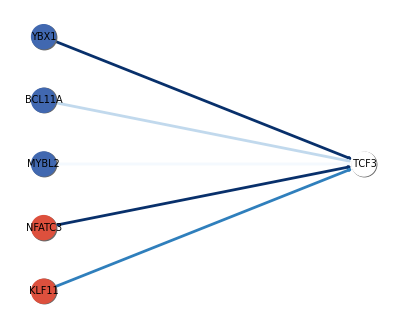

['YBX1'] ['NFATC3', 'KLF11']
TCF3 *= ( YBX1 ) and not (NFATC3 or KLF11 )


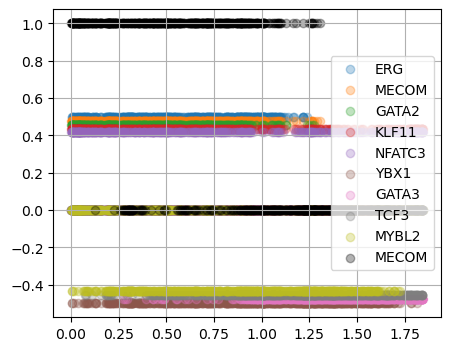

gene  MECOM  run # 0


Epoch: 169, Loss: 0.029103036461906: 100%|████| 170/170 [00:08<00:00, 20.98it/s]


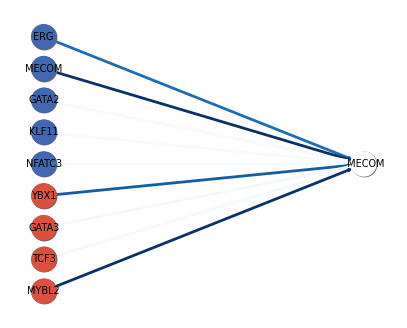

gene  MECOM  run # 1


Epoch: 169, Loss: 0.029484088617292317: 100%|█| 170/170 [00:07<00:00, 22.46it/s]


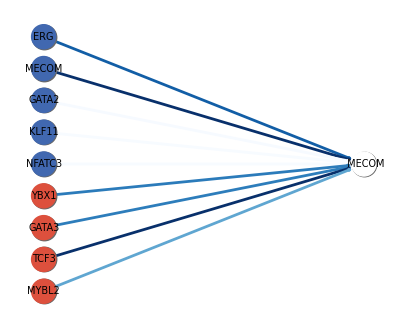

gene  MECOM  run # 2


Epoch: 169, Loss: 0.03272055665200407: 100%|██| 170/170 [00:07<00:00, 22.13it/s]


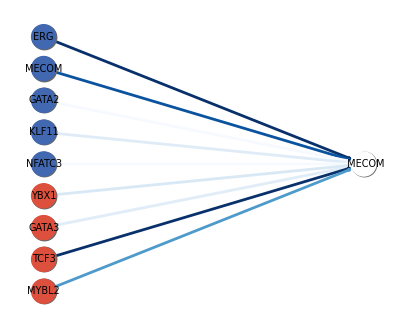

gene  MECOM  run # 3


Epoch: 169, Loss: 0.029158011248165912: 100%|█| 170/170 [00:07<00:00, 22.27it/s]


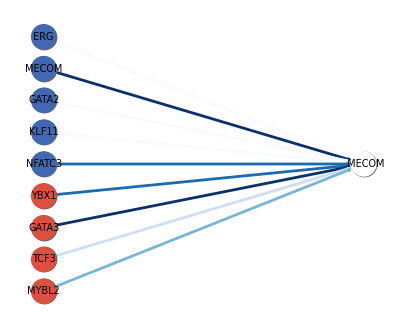

gene  MECOM  run # 4


Epoch: 169, Loss: 0.023667445914311844: 100%|█| 170/170 [00:08<00:00, 20.94it/s]


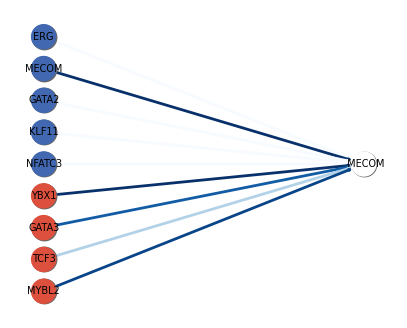

gene  MECOM  run # 5


Epoch: 169, Loss: 0.023554725233804096: 100%|█| 170/170 [00:07<00:00, 22.68it/s]


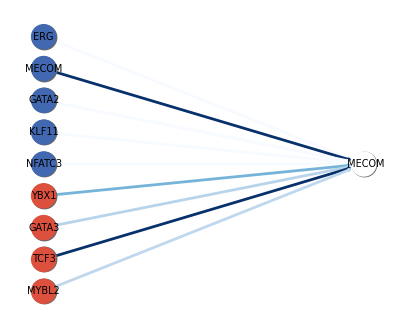

gene  MECOM  run # 6


Epoch: 169, Loss: 0.02409716526215727: 100%|██| 170/170 [00:10<00:00, 15.51it/s]


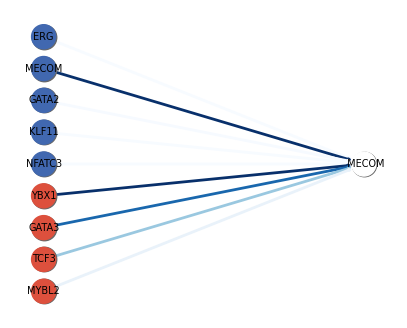

gene  MECOM  run # 7


Epoch: 169, Loss: 0.024057328870350666: 100%|█| 170/170 [00:07<00:00, 21.95it/s]


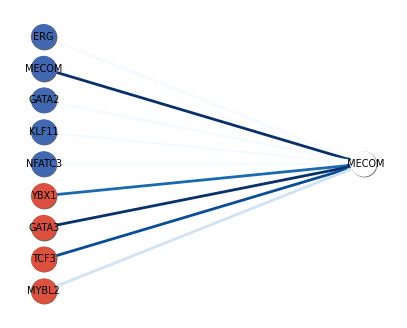

gene  MECOM  run # 8


Epoch: 169, Loss: 0.023881999775767326: 100%|█| 170/170 [00:06<00:00, 25.06it/s]


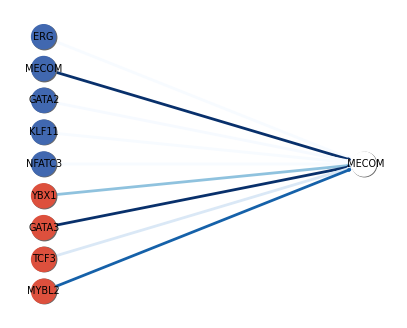

gene  MECOM  run # 9


Epoch: 169, Loss: 0.028612970967184414: 100%|█| 170/170 [00:06<00:00, 24.60it/s]


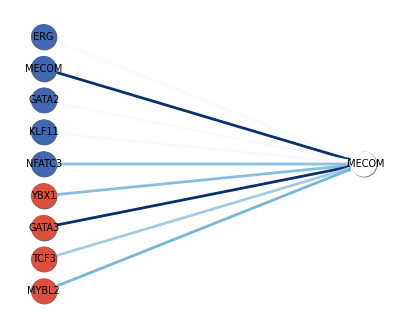

['MECOM'] ['YBX1', 'GATA3', 'TCF3']
MECOM *= ( MECOM ) and not (YBX1 or GATA3 or TCF3 )


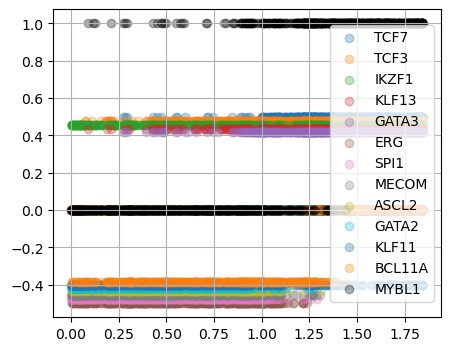

gene  MYBL1  run # 0


Epoch: 169, Loss: 0.11884539371187036: 100%|██| 170/170 [00:08<00:00, 20.49it/s]


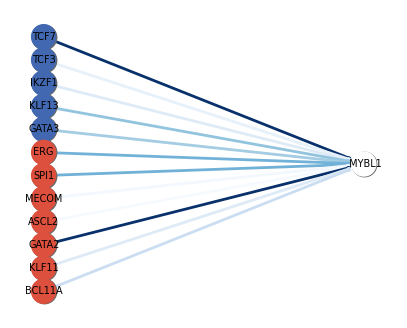

gene  MYBL1  run # 1


Epoch: 169, Loss: 0.10363790392875671: 100%|██| 170/170 [00:07<00:00, 22.31it/s]


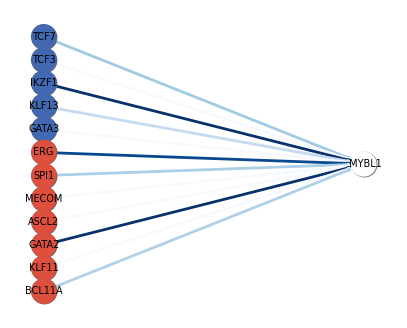

gene  MYBL1  run # 2


Epoch: 169, Loss: 0.09706924991174178: 100%|██| 170/170 [00:07<00:00, 22.61it/s]


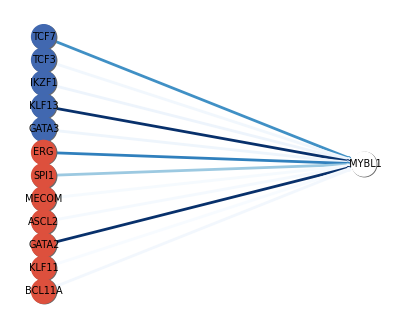

gene  MYBL1  run # 3


Epoch: 169, Loss: 0.10252213749018582: 100%|██| 170/170 [00:07<00:00, 22.68it/s]


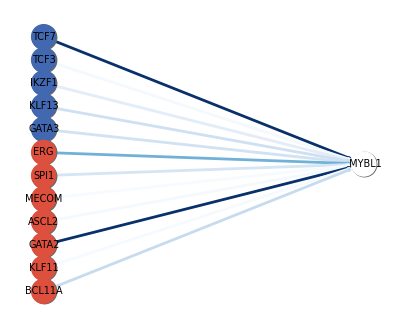

gene  MYBL1  run # 4


Epoch: 169, Loss: 0.11929461495442824: 100%|██| 170/170 [00:07<00:00, 22.76it/s]


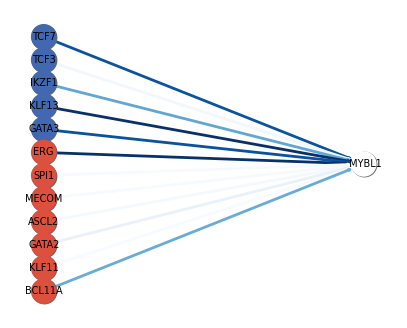

gene  MYBL1  run # 5


Epoch: 169, Loss: 0.10378882695328105: 100%|██| 170/170 [00:07<00:00, 21.29it/s]


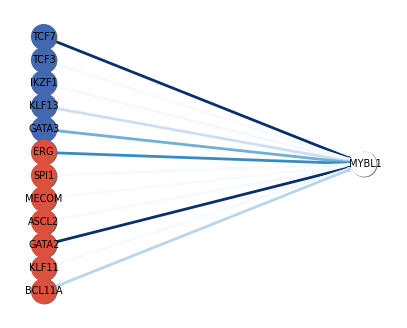

gene  MYBL1  run # 6


Epoch: 169, Loss: 0.1016986837441271: 100%|███| 170/170 [00:08<00:00, 20.47it/s]


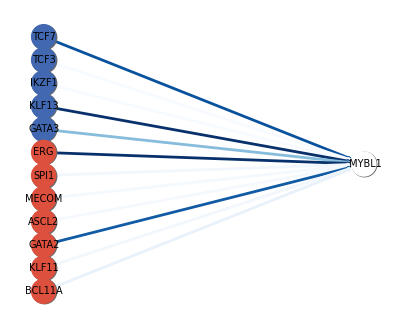

gene  MYBL1  run # 7


Epoch: 169, Loss: 0.11026736890727823: 100%|██| 170/170 [00:08<00:00, 19.92it/s]


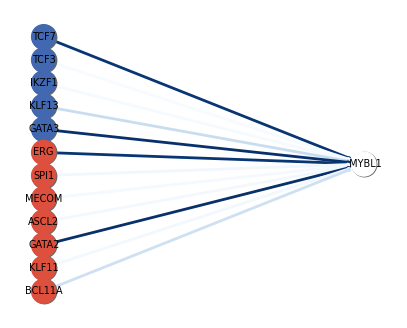

gene  MYBL1  run # 8


Epoch: 169, Loss: 0.09361113675616005: 100%|██| 170/170 [00:08<00:00, 19.91it/s]


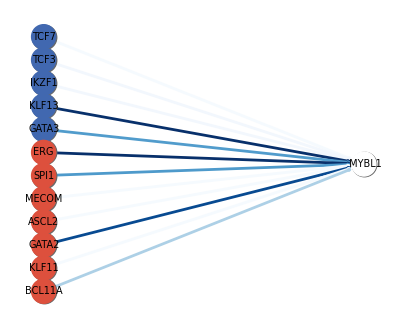

gene  MYBL1  run # 9


Epoch: 169, Loss: 0.11744268983602524: 100%|██| 170/170 [00:15<00:00, 10.78it/s]


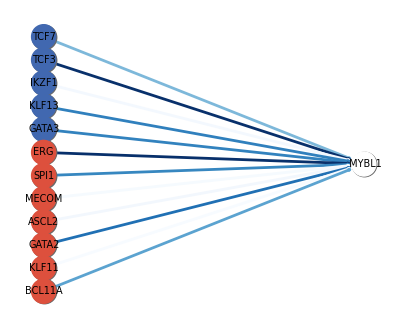

['TCF7', 'KLF13'] ['ERG', 'GATA2', 'BCL11A']
MYBL1 *= ( TCF7 and KLF13 ) and not (ERG or GATA2 or BCL11A )


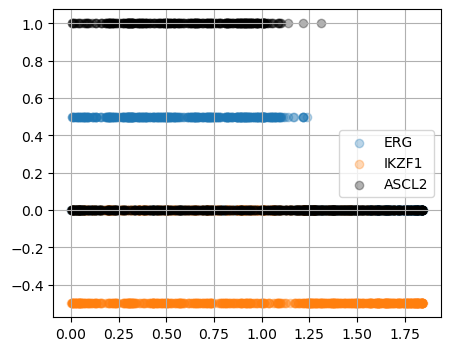

gene  ASCL2  run # 0


Epoch: 169, Loss: 0.13433324681086975: 100%|██| 170/170 [00:09<00:00, 17.59it/s]


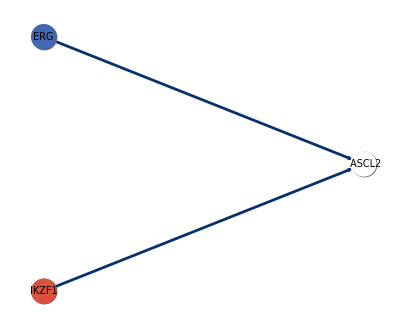

gene  ASCL2  run # 1


Epoch: 169, Loss: 0.12302494929595427: 100%|██| 170/170 [00:06<00:00, 25.16it/s]


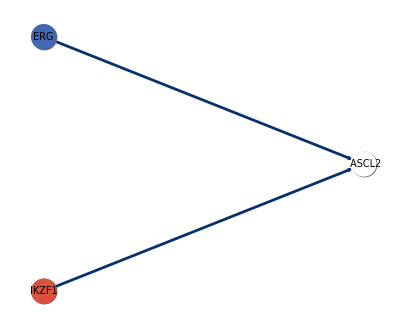

gene  ASCL2  run # 2


Epoch: 169, Loss: 0.1395924910902977: 100%|███| 170/170 [00:08<00:00, 19.79it/s]


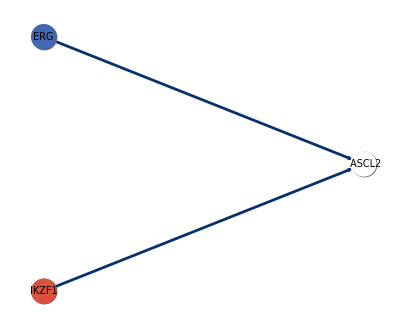

gene  ASCL2  run # 3


Epoch: 169, Loss: 0.13356442952697928: 100%|██| 170/170 [00:07<00:00, 22.59it/s]


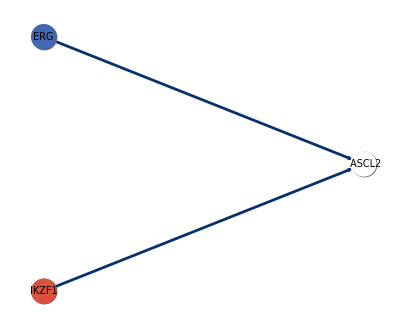

gene  ASCL2  run # 4


Epoch: 169, Loss: 0.12239381603219292: 100%|██| 170/170 [00:07<00:00, 22.13it/s]


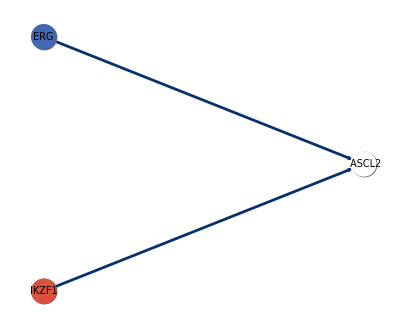

gene  ASCL2  run # 5


Epoch: 169, Loss: 0.13130844655362042: 100%|██| 170/170 [00:06<00:00, 26.70it/s]


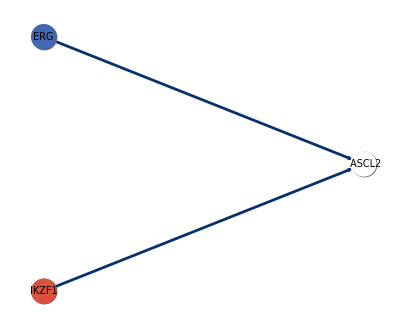

gene  ASCL2  run # 6


Epoch: 169, Loss: 0.13862142305482517: 100%|██| 170/170 [00:06<00:00, 25.14it/s]


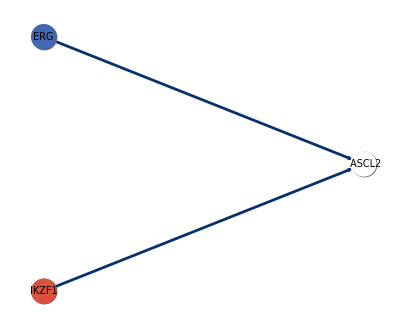

gene  ASCL2  run # 7


Epoch: 169, Loss: 0.1191725114529783: 100%|███| 170/170 [00:07<00:00, 24.11it/s]


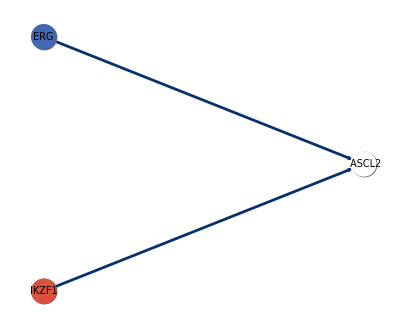

gene  ASCL2  run # 8


Epoch: 169, Loss: 0.13145661150867288: 100%|██| 170/170 [00:08<00:00, 21.05it/s]


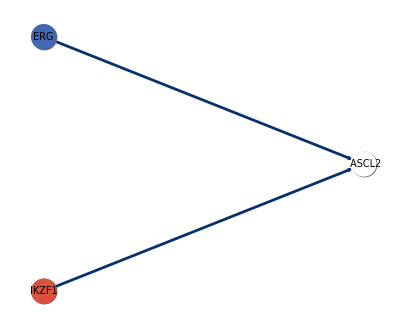

gene  ASCL2  run # 9


Epoch: 169, Loss: 0.13409234989773144: 100%|██| 170/170 [00:07<00:00, 22.37it/s]


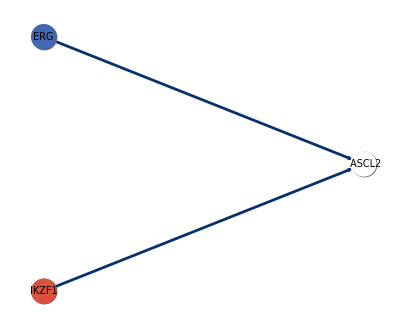

['ERG'] ['IKZF1']
ASCL2 *= ( ERG ) and not (IKZF1 )


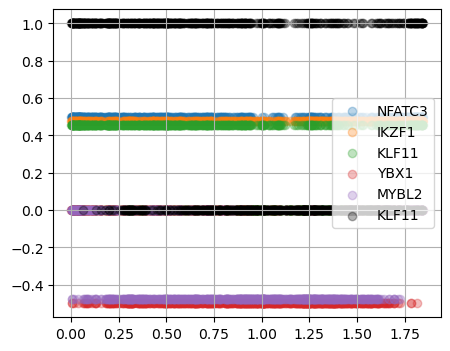

gene  KLF11  run # 0


Epoch: 169, Loss: 0.02626384523781863: 100%|██| 170/170 [00:07<00:00, 23.68it/s]


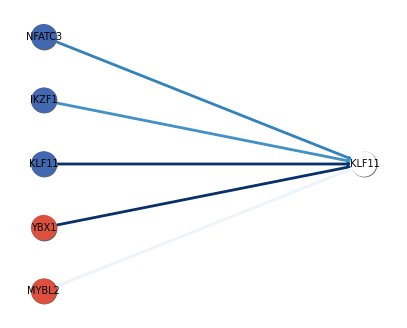

gene  KLF11  run # 1


Epoch: 169, Loss: 0.01577124168927019: 100%|██| 170/170 [00:07<00:00, 23.91it/s]


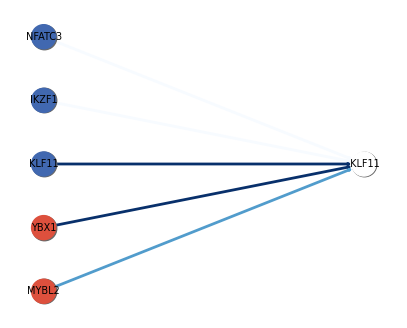

gene  KLF11  run # 2


Epoch: 169, Loss: 0.09654829447919672: 100%|██| 170/170 [00:07<00:00, 22.04it/s]


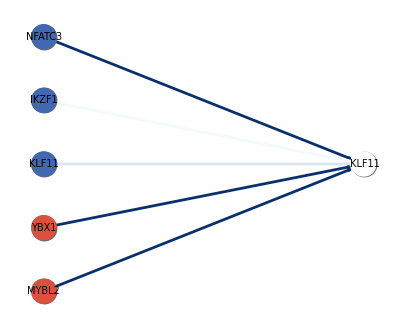

gene  KLF11  run # 3


Epoch: 169, Loss: 0.01578537831929597: 100%|██| 170/170 [00:07<00:00, 24.09it/s]


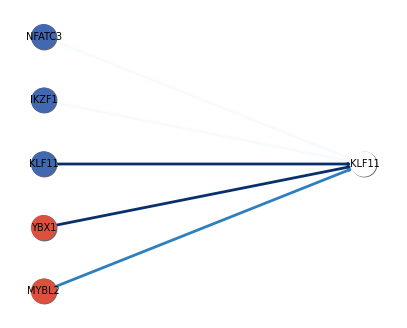

gene  KLF11  run # 4


Epoch: 169, Loss: 0.015836846760728142: 100%|█| 170/170 [00:07<00:00, 23.43it/s]


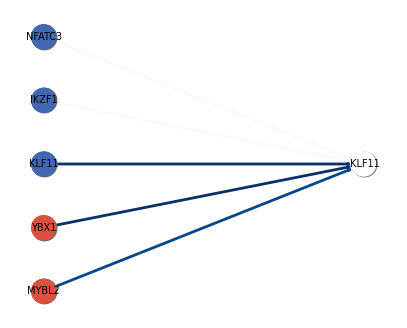

gene  KLF11  run # 5


Epoch: 169, Loss: 0.01585511321371252: 100%|██| 170/170 [00:07<00:00, 24.24it/s]


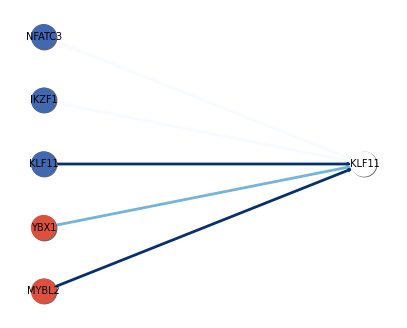

gene  KLF11  run # 6


Epoch: 169, Loss: 0.015761593356728554: 100%|█| 170/170 [00:07<00:00, 23.98it/s]


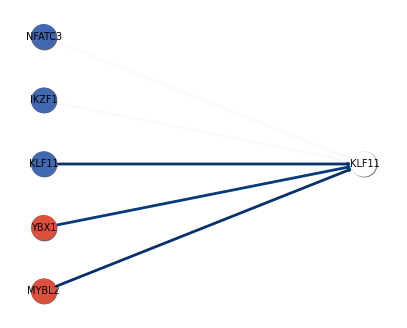

gene  KLF11  run # 7


Epoch: 169, Loss: 0.015728252685882828: 100%|█| 170/170 [00:06<00:00, 24.34it/s]


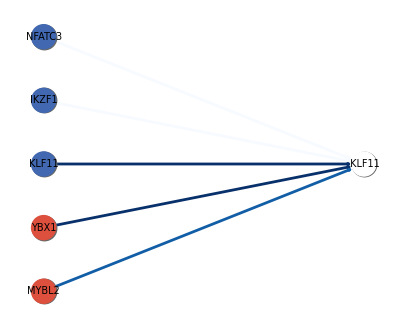

gene  KLF11  run # 8


Epoch: 169, Loss: 0.015883512794971466: 100%|█| 170/170 [00:07<00:00, 23.43it/s]


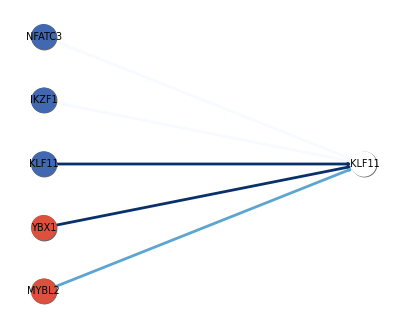

gene  KLF11  run # 9


Epoch: 169, Loss: 0.020442817190831356: 100%|█| 170/170 [00:07<00:00, 24.20it/s]


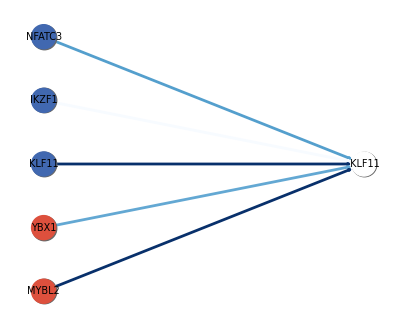

['KLF11'] ['YBX1', 'MYBL2']
KLF11 *= ( KLF11 ) and not (YBX1 or MYBL2 )


In [ ]:
GRN_rules=[]

#Target_gene='KLF5'#'IKZF3'#'NFATC3'#'ETS1'#'SPI1'#'TCF3'#'GATA3'#'GATA2'#'BCL11A'#'YBX1'#'TCF7'

for Target_gene in gene_list:
    #_____creating data for target gene:  output act rep T
    sub_g_g=g_g_interactions.loc[Target_gene]
    act_genes=list(sub_g_g.loc[sub_g_g['relation']==1]['from.gene'])
    act_genes=list(set(act_genes)) # make sure no duplicate

    rep_genes=list(sub_g_g.loc[sub_g_g['relation']==-1]['from.gene'])
    rep_genes=list(set(rep_genes)) # make sure no duplicate

    target_expression=torch.tensor(expression[Target_gene]).float()
    act_expression=torch.tensor(np.array(expression[act_genes])).float()
    rep_expression=torch.tensor(np.array(expression[rep_genes])).float()

    #_______________visualize
    i=0
    for g in act_genes:
        y=np.array(expression[g])
        x=T
        plt.scatter(PT, y * (10 / (20 + i)), label=f'{g}', alpha=0.3)
        i=i+1
    i=0
    for g in rep_genes:
        y=np.array(expression[g])
        x=T
        plt.scatter(PT, -y * (10 / (20 + i)), label=f'{g}', alpha=0.3)
        i=i+1
    plt.scatter(PT, target_expression, label=f'{Target_gene}', alpha=0.3,c='black')
    plt.legend(loc="center right")
    plt.grid(True)
    plt.show()


    #_______________________parameters
    NUM_EPOCHS = 170
    LEARNING_RATE = 0.0000000001
    BATCH_SIZE = 100
    N_run=10
    reg_skip=100


    #_______________________________________REG TIME___________
    # the files that come from upstream (expression + biarized)
     #cells(rows) x colums (genes)

    # rolling back and cutting the tails
    syn_data_output=torch.roll(target_expression,-reg_skip)
    # cutting the tails:
    syn_data_output=target_expression[:-reg_skip]
    syn_data_input_act=act_expression[:-reg_skip]
    syn_data_input_rep=rep_expression[:-reg_skip]
    T=PT[:-reg_skip]
    #_______________________________________REG TIME___________


    Weith_matrix=pd.DataFrame(np.zeros((N_run,len(act_genes)+len(rep_genes))),
                 columns= act_genes+rep_genes )

    for i in range(N_run):
        print('gene ',Target_gene,' run #', i)

        And_Or_dataset_train = ExpressionData_And_Or( x_act=syn_data_input_act,
                                                  x_rep=syn_data_input_rep, y=syn_data_output,t=T)

        sampler = AndOrSampler(And_Or_dataset_train, replacement=True)
        And_Or_data_loader_train = DataLoader(dataset=And_Or_dataset_train, sampler=sampler, batch_size=BATCH_SIZE)

        And_Or_model = And_Or_Network(syn_data_input_act.shape[1],syn_data_input_rep.shape[1])
        model, losses = training_loop_And_Or(And_Or_model, And_Or_data_loader_train,
                                      epochs=NUM_EPOCHS, regularization_lambda=0.005,)

        with torch.no_grad():
            predictions = model(syn_data_input_act,syn_data_input_rep)

        output_data = syn_data_output.numpy()
        predictions = predictions.numpy()
        w_act=np.array(torch.abs(model.regulator_layer.weight_and.detach().T))
        w_rep=np.array(torch.abs(model.regulator_layer.weight_or.detach().T))
        w_bin_act=np.heaviside(np.array(w_act/np.max(w_act))-0.2 ,0 )
        w_bin_rep=np.heaviside(np.array(w_rep/np.max(w_rep))-0.2 ,0 )
        w_bin_act_rep=np.concatenate((w_bin_act,w_bin_rep),axis=0)
        Weith_matrix.iloc[i,:]=w_bin_act_rep[:,0]


        # plt.figure(figsize=(7, 5))
        # plt.plot(losses[:20], color='blue', linestyle='-', linewidth=2, label='Training Loss')
        # plt.show()

        # plt.scatter(T, output_data, c='r', alpha=0.1, label='Truth $y$')
        # plt.scatter(T, predictions, c='b', alpha=0.1, label='Prediction $\hat{y}$', linestyle=":")
        # plt.legend()
        # plt.show()


        visualize_learned_GRN_And_Or(weight_act=w_act,weight_rep=w_rep,
                                     target_name=Target_gene,
                                     act_name=act_genes,
                                    rep_name=rep_genes)


    ##_____________model selection______________________________________
    # _________calculating the frequencies and weits of the best rule
    Weigh_P=Weith_matrix.sum(axis=0) #
    rules_matrix=Weith_matrix.drop_duplicates() # no doplicates
    number_of_present_genes=(rules_matrix!=0).sum(axis=1) # how many genes are present in the rule

    p_a=Weigh_P[:len(act_genes)]/Weigh_P[:len(act_genes)].sum() # P of activaotrs
    p_r=Weigh_P[len(act_genes):]/Weigh_P[len(act_genes):].sum() #P of repressora
    p_g=np.concatenate( (p_a,p_r) ) # both
    val_g=p_g* rules_matrix  # multiply
    val_rules=val_g.sum(axis=1) # sum to get rule scores
    val_rules=val_rules/number_of_present_genes # normalize to the number of genes in the rule

    max_val_rule_index=val_rules.argmax() # index of rule with max val
    selected_rule=rules_matrix.iloc[max_val_rule_index,:]

    # _________get the selected acts and repressors:
    acts_=selected_rule[act_genes]
    acts_=acts_[acts_==1.0]
    acts_=list(acts_.index)

    reps_=selected_rule[rep_genes]
    reps_=reps_[reps_==1.0]
    reps_=list(reps_.index)
    print(acts_,reps_)

    #____________eiritng the rule:

    target_rule=Target_gene+' *='
    # activators
    for i in range(len(acts_)):
        if i==0:
            target_rule=target_rule + ' ( '+acts_[i]
        elif i== (len(acts_)-1):
            target_rule=target_rule + ' and '+acts_[i]
        else:
            target_rule=target_rule + ' and '+acts_[i]
    target_rule=target_rule + ' )'

    # repressor
    for i in range(len(reps_)):
        if i==0:
            target_rule=target_rule + ' and not ('+reps_[i]
        elif i== (len(reps_)-1):
            target_rule=target_rule + ' or '+reps_[i]
        else:
            target_rule=target_rule + ' or '+reps_[i]

    target_rule=target_rule + ' )'
    #____________eiritng the rule:
    print(target_rule)
    GRN_rules.append(target_rule)

In [ ]:
GRN_rules

['GATA3 *= ( TCF3 ) and not (ASCL2 and GATA2 )',
 'NFATC3 *= ( NFATC3 ) and not (ERG and ASCL2 and BCL11A )',
 'ETS1 *= ( STAT4 and KLF13 ) and not (BCL11A )',
 'IKZF3 *= ( ETS1 ) and not (BCL11A )',
 'TCF7 *= ( GATA3 ) and not (SPI1 )',
 'KLF5 *= ( TCF7 ) and not (ERG and BCL11A )',
 'BCL11A *= ( ERG and MYBL2 ) and not (IKZF1 )',
 'STAT4 *= ( KLF5 and MYBL1 ) and not (BCL11A )',
 'IKZF1 *= ( IKZF1 ) and not (ERG )',
 'YBX1 *= ( MYBL2 ) and not (IKZF1 )',
 'MYBL2 *= ( ASCL2 ) and not (IKZF1 )',
 'KLF13 *= ( GATA3 and IKZF1 ) and not (SPI1 and GATA2 )',
 'ERG *= ( ERG ) and not (IKZF1 )',
 'SPI1 *= ( SPI1 ) and not (TCF3 )',
 'GATA2 *= ( GATA2 ) and not (IKZF1 )',
 'TCF3 *= ( YBX1 ) and not (KLF11 )',
 'MECOM *= ( MECOM ) and not (YBX1 and TCF3 )',
 'MYBL1 *= ( GATA3 ) and not (ERG )',
 'ASCL2 *= ( ERG ) and not (IKZF1 )',
 'KLF11 *= ( KLF11 ) and not (YBX1 )']

# 4 Implementing the gene herarchy as a loss regularization

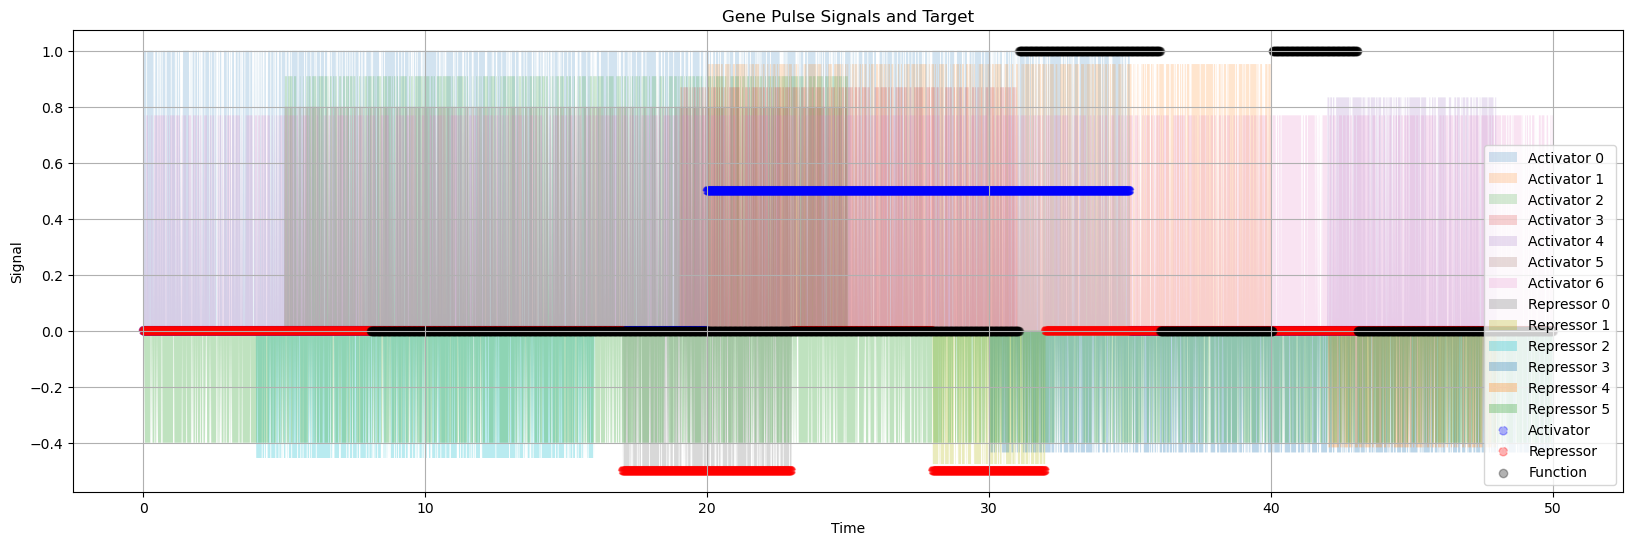

In [ ]:
# A=[ (15, 10),(15, 20),(30, 10) ,(25, 6), (45, 3),(15, 10),(15, 40)]
# R=[ (20, 3),(30, 2),(10, 6) ,(40, 10), (45, 3),(15, 35)]

A=[ (15, 20),(30, 10),(15, 10),(25, 6), (45, 3),(15, 10),(15, 40)]
R=[ (20, 3),(30, 2),(10, 6) ,(40, 10), (45, 3),(15, 35)]

GRN_A = [0,1]
GRN_R = [0,1]

T = np.linspace(0, 50, 3100)
noise_level_dropout=0.1
noise_level_biological=0.1
reg_skip=500

syn_data_input_act, syn_data_input_rep, syn_data_output = create_synthetic_data(A, R, GRN_A, GRN_R, T,
                                                                reg_skip=reg_skip,plot=True, noise_level_dropout=noise_level_dropout,
                                                                            noise_level_biological=noise_level_biological)

T=T[reg_skip:]


In [ ]:
# again alll we have:
syn_data_output
syn_data_input_act
syn_data_input_rep
T

#_______________________________________REG TIME___________
# the files that come from upstream (expression + biarized)
 #cells(rows) x colums (genes)

# rolling back and cutting the tails
syn_data_output=torch.roll(syn_data_output,-reg_skip)
# cutting the tails:
syn_data_output=syn_data_output[:-reg_skip]
syn_data_input_act=syn_data_input_act[:-reg_skip]
syn_data_input_rep=syn_data_input_rep[:-reg_skip]
T=T[:-reg_skip]
#_______________________________________REG TIME___________

In [ ]:
#order of activators:
tr_A=[0,20,5,19,42,5,0]#transition_point_of_ac
tr_R=[17,28,4,30,42,0]#transition_point_of_rep
tr_O=[23]# transition_point_of_output
W_h_A=np.heaviside(torch.tensor(tr_A)-torch.tensor(tr_O),0)
W_h_A

tensor([0., 0., 0., 0., 1., 0., 0.], dtype=torch.float64)

Epoch: 99, Loss: 0.22189878047459516: 100%|███| 100/100 [00:07<00:00, 14.28it/s]


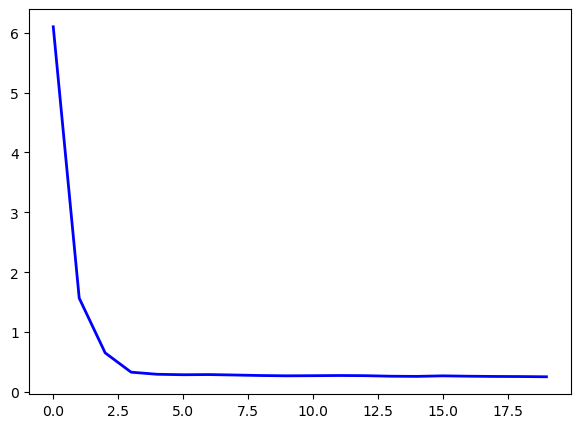

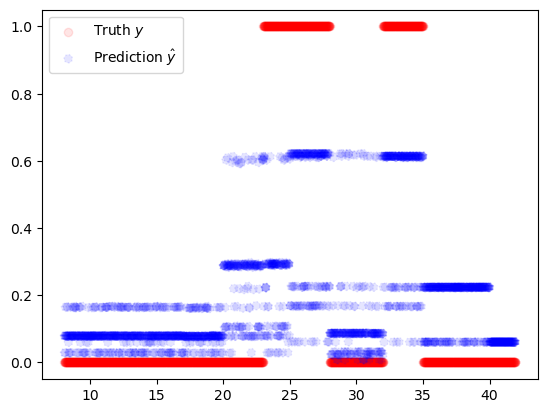

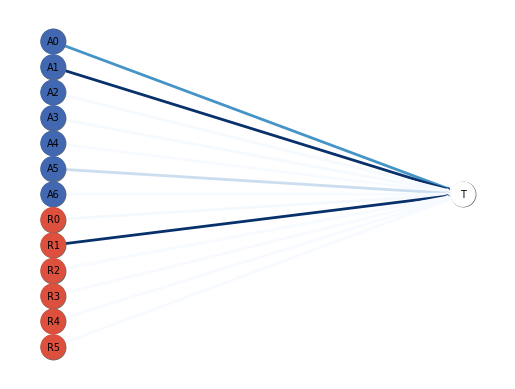

In [ ]:
# does it learn??? apparently not
NUM_EPOCHS = 100
LEARNING_RATE = 0.0000000001
BATCH_SIZE = 100






And_Or_dataset_train = ExpressionData_And_Or( x_act=syn_data_input_act,
                                          x_rep=syn_data_input_rep, y=syn_data_output,t=T)

sampler = AndOrSampler(And_Or_dataset_train, replacement=True)
And_Or_data_loader_train = DataLoader(dataset=And_Or_dataset_train, sampler=sampler, batch_size=BATCH_SIZE)

And_Or_model = And_Or_Network(syn_data_input_act.shape[1],syn_data_input_rep.shape[1])

model, losses = training_loop_And_Or(And_Or_model, And_Or_data_loader_train,
                              epochs=NUM_EPOCHS, regularization_lambda=0.015,
                                     lambda_heirarchy=0.01,W_h_A=W_h_A)


plt.figure(figsize=(7, 5))
plt.plot(losses[:20], color='blue', linestyle='-', linewidth=2, label='Training Loss')
plt.show()


with torch.no_grad():
    predictions = model(syn_data_input_act,syn_data_input_rep)

output_data = syn_data_output.numpy()
predictions = predictions.numpy()

plt.scatter(T, output_data, c='r', alpha=0.1, label='Truth $y$')
plt.scatter(T, predictions, c='b', alpha=0.1, label='Prediction $\hat{y}$', linestyle=":")
plt.legend()
plt.show()

w_act=np.array(torch.abs(model.regulator_layer.weight_and.detach().T))
w_rep=np.array(torch.abs(model.regulator_layer.weight_or.detach().T))
visualize_learned_GRN_And_Or(weight_act=w_act,weight_rep=w_rep)